In [1]:
import pandas as pd
import numpy as np
from helpers import *
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
from joblib import dump, load

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, classification_report
from category_encoders import CountEncoder
from category_encoders.target_encoder import TargetEncoder
seed = 42

In [2]:
# Загрузим данные и результаты baseline
data = pd.read_csv('bank.csv')
data = data.drop('duration', axis=1)
result_cross_val_baseline = load('result_cross_val_baseline_v2.joblib')
result_test_baseline = load('result_test_baseline_v2.joblib')

### Feature engineering
Далее мы будем создавать новые, либо изменять старые признаки для улучшения метрик моделей.
Для обучения моделей на измененных признаках - будем использовать в качестве основы пайплайн с предыдущего шага (baseline) 

## Бинаризация и частотное кодирование
Бинаризуем признак age (удалив оригинальный столбец) и применим частотное кодирование к признаку day.
При частотном кодировании значения признака заменяются на частоту встречаемости признака в датасете

In [3]:
df = data.copy()
# бинаризируем признак age
age_bins = [0,25,35,45,55,65,1000]
age_labels = ['<25', '25-34', '35-44', '45-54', '55-64', '65+']
df['age'] = pd.cut(df['age'], bins=age_bins, labels = age_labels)

df['day'] = df['day'].astype(str)

In [4]:
result_cross_val_bin_count, result_test_bin_count, models_bin_count = run_experiment_pipeline(df, count_cols=['day'])

In [5]:
print('')
print('Результаты на кросс-валидации')
print('')
display(result_cross_val_bin_count)
print('')
print('Результаты на тестовой выборке')
print('')
display(result_test_bin_count)
print('')
print('Сравнение полученного результата с baseline (на кросс-валидации)')
print('')
display(result_cross_val_bin_count - result_cross_val_baseline)


Результаты на кросс-валидации



,roc_auc,accuracy,precision,recall,f1
LogisticRegression,0.7656,0.7084,0.7489,0.5783,0.6525
RandomForest,0.7637,0.7106,0.7247,0.6282,0.6727
XGBoost,0.7714,0.7106,0.7194,0.6386,0.6765



Результаты на тестовой выборке



,roc_auc,accuracy,precision,recall,f1
LogisticRegression,0.762022,0.704881,0.752212,0.562382,0.643591
RandomForest,0.759180,0.711151,0.734926,0.610586,0.667011
XGBoost,0.761459,0.706673,0.722161,0.619093,0.666667



Сравнение полученного результата с baseline (на кросс-валидации)



,roc_auc,accuracy,precision,recall,f1
LogisticRegression,0.0025,0.0028,0.0063,-0.0012,0.0017
RandomForest,-0.0132,-0.0145,-0.0197,-0.0116,-0.0152
XGBoost,-0.0061,-0.0067,-0.0127,0.0019,-0.0044


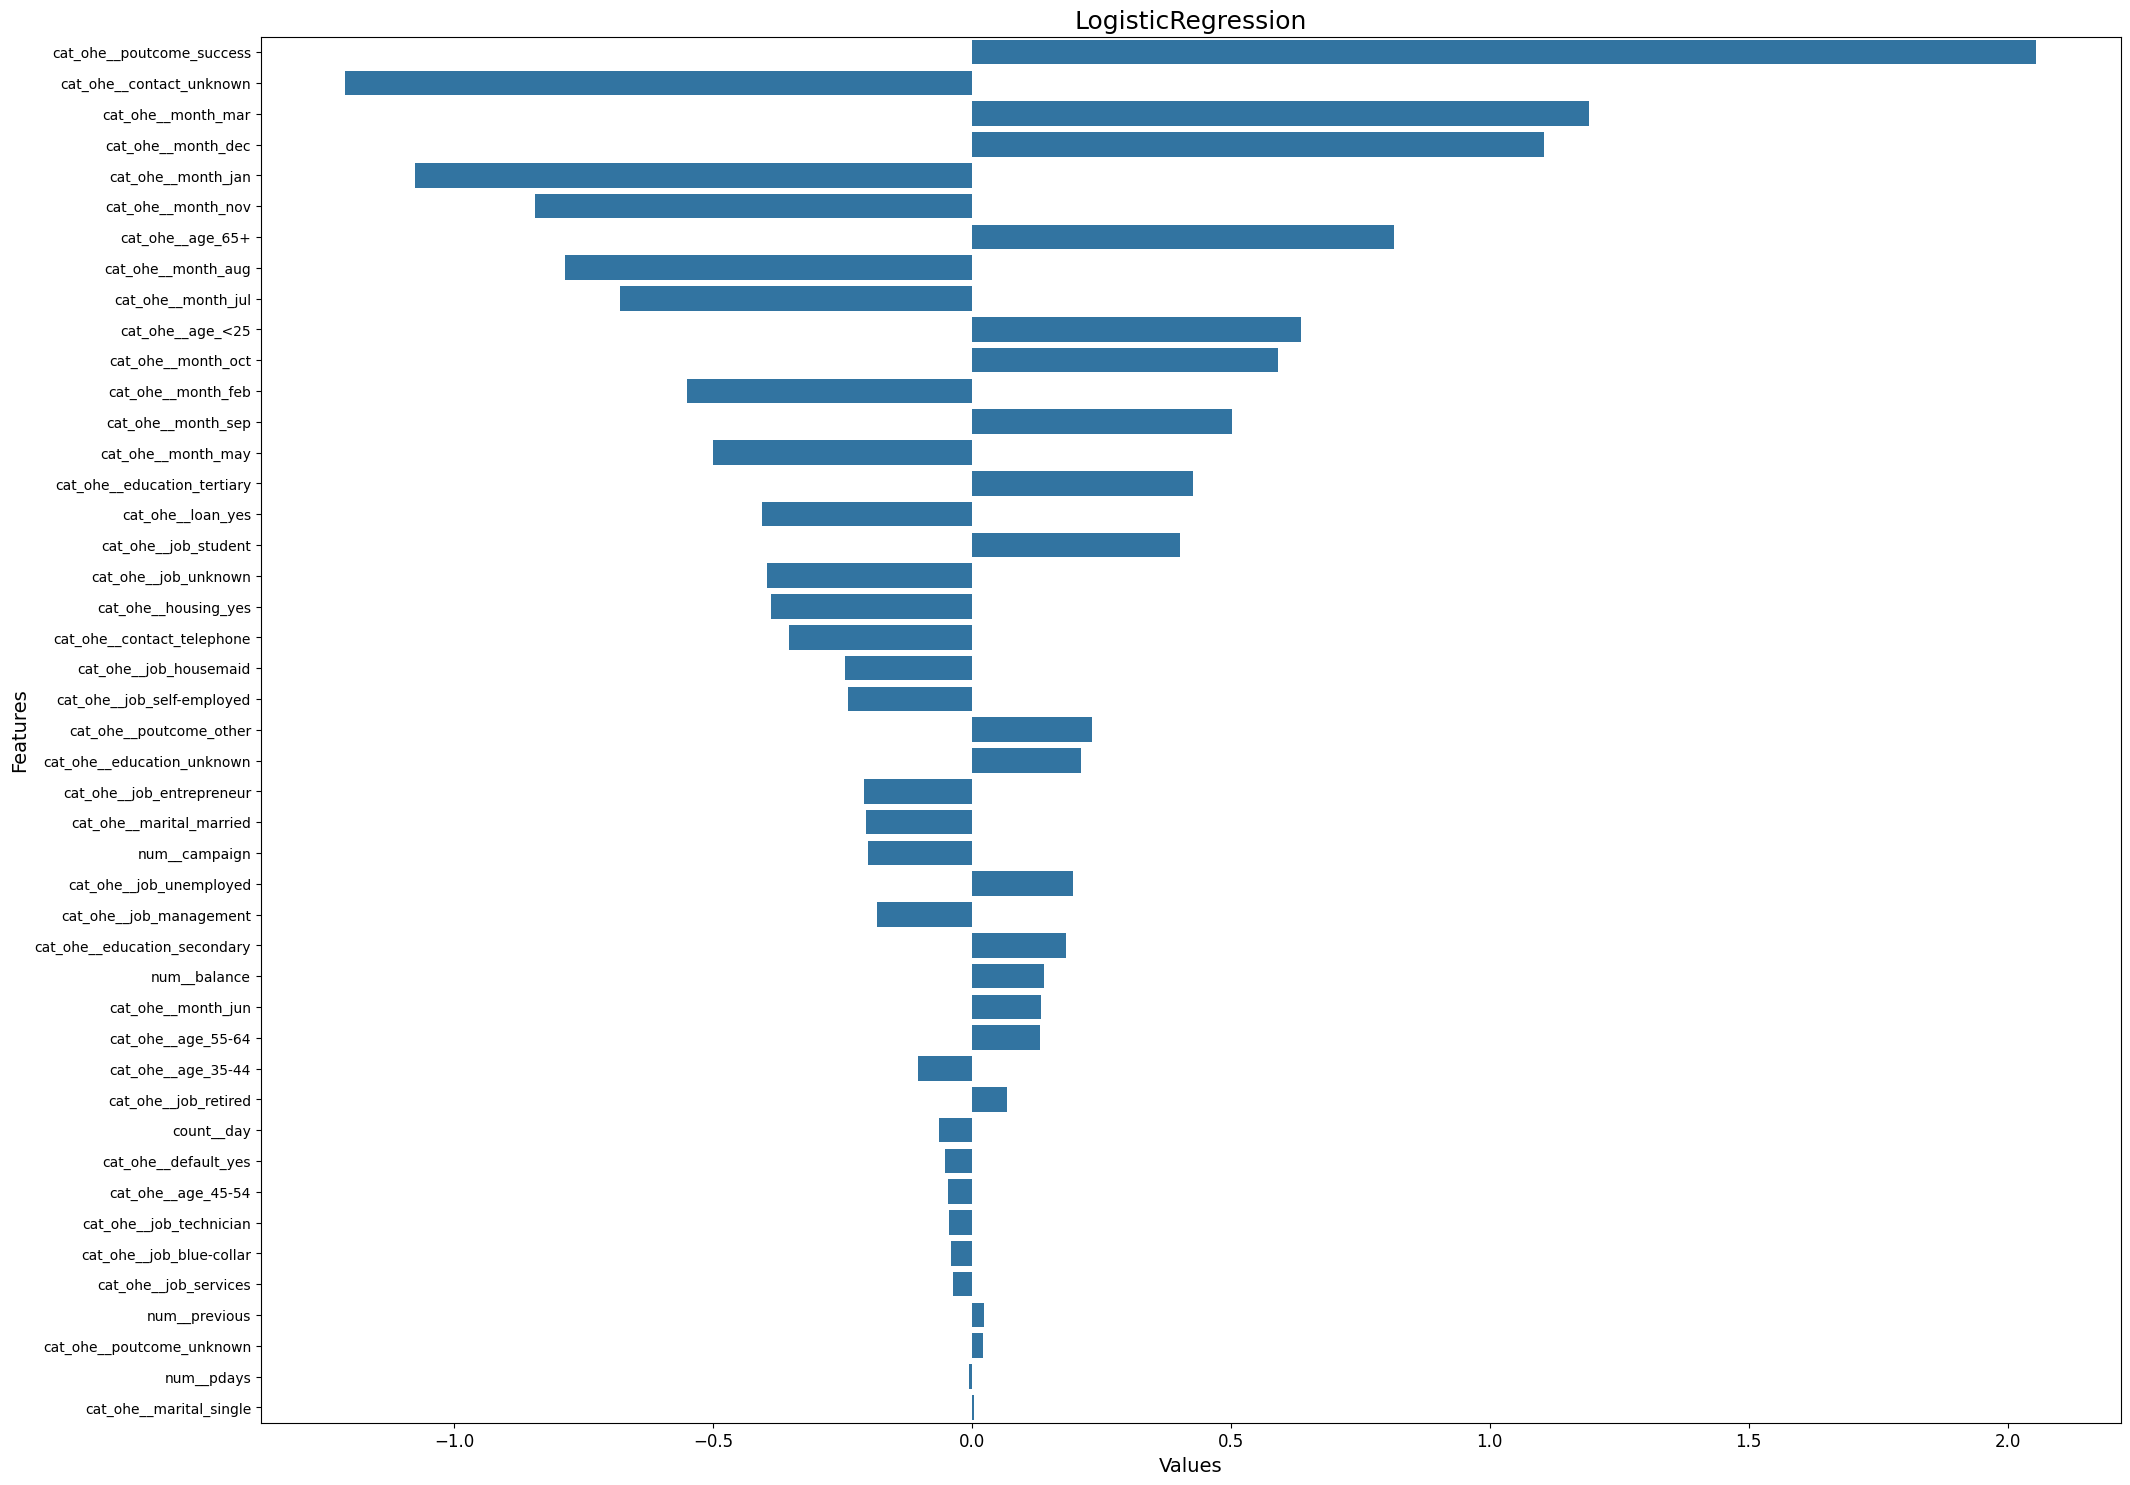

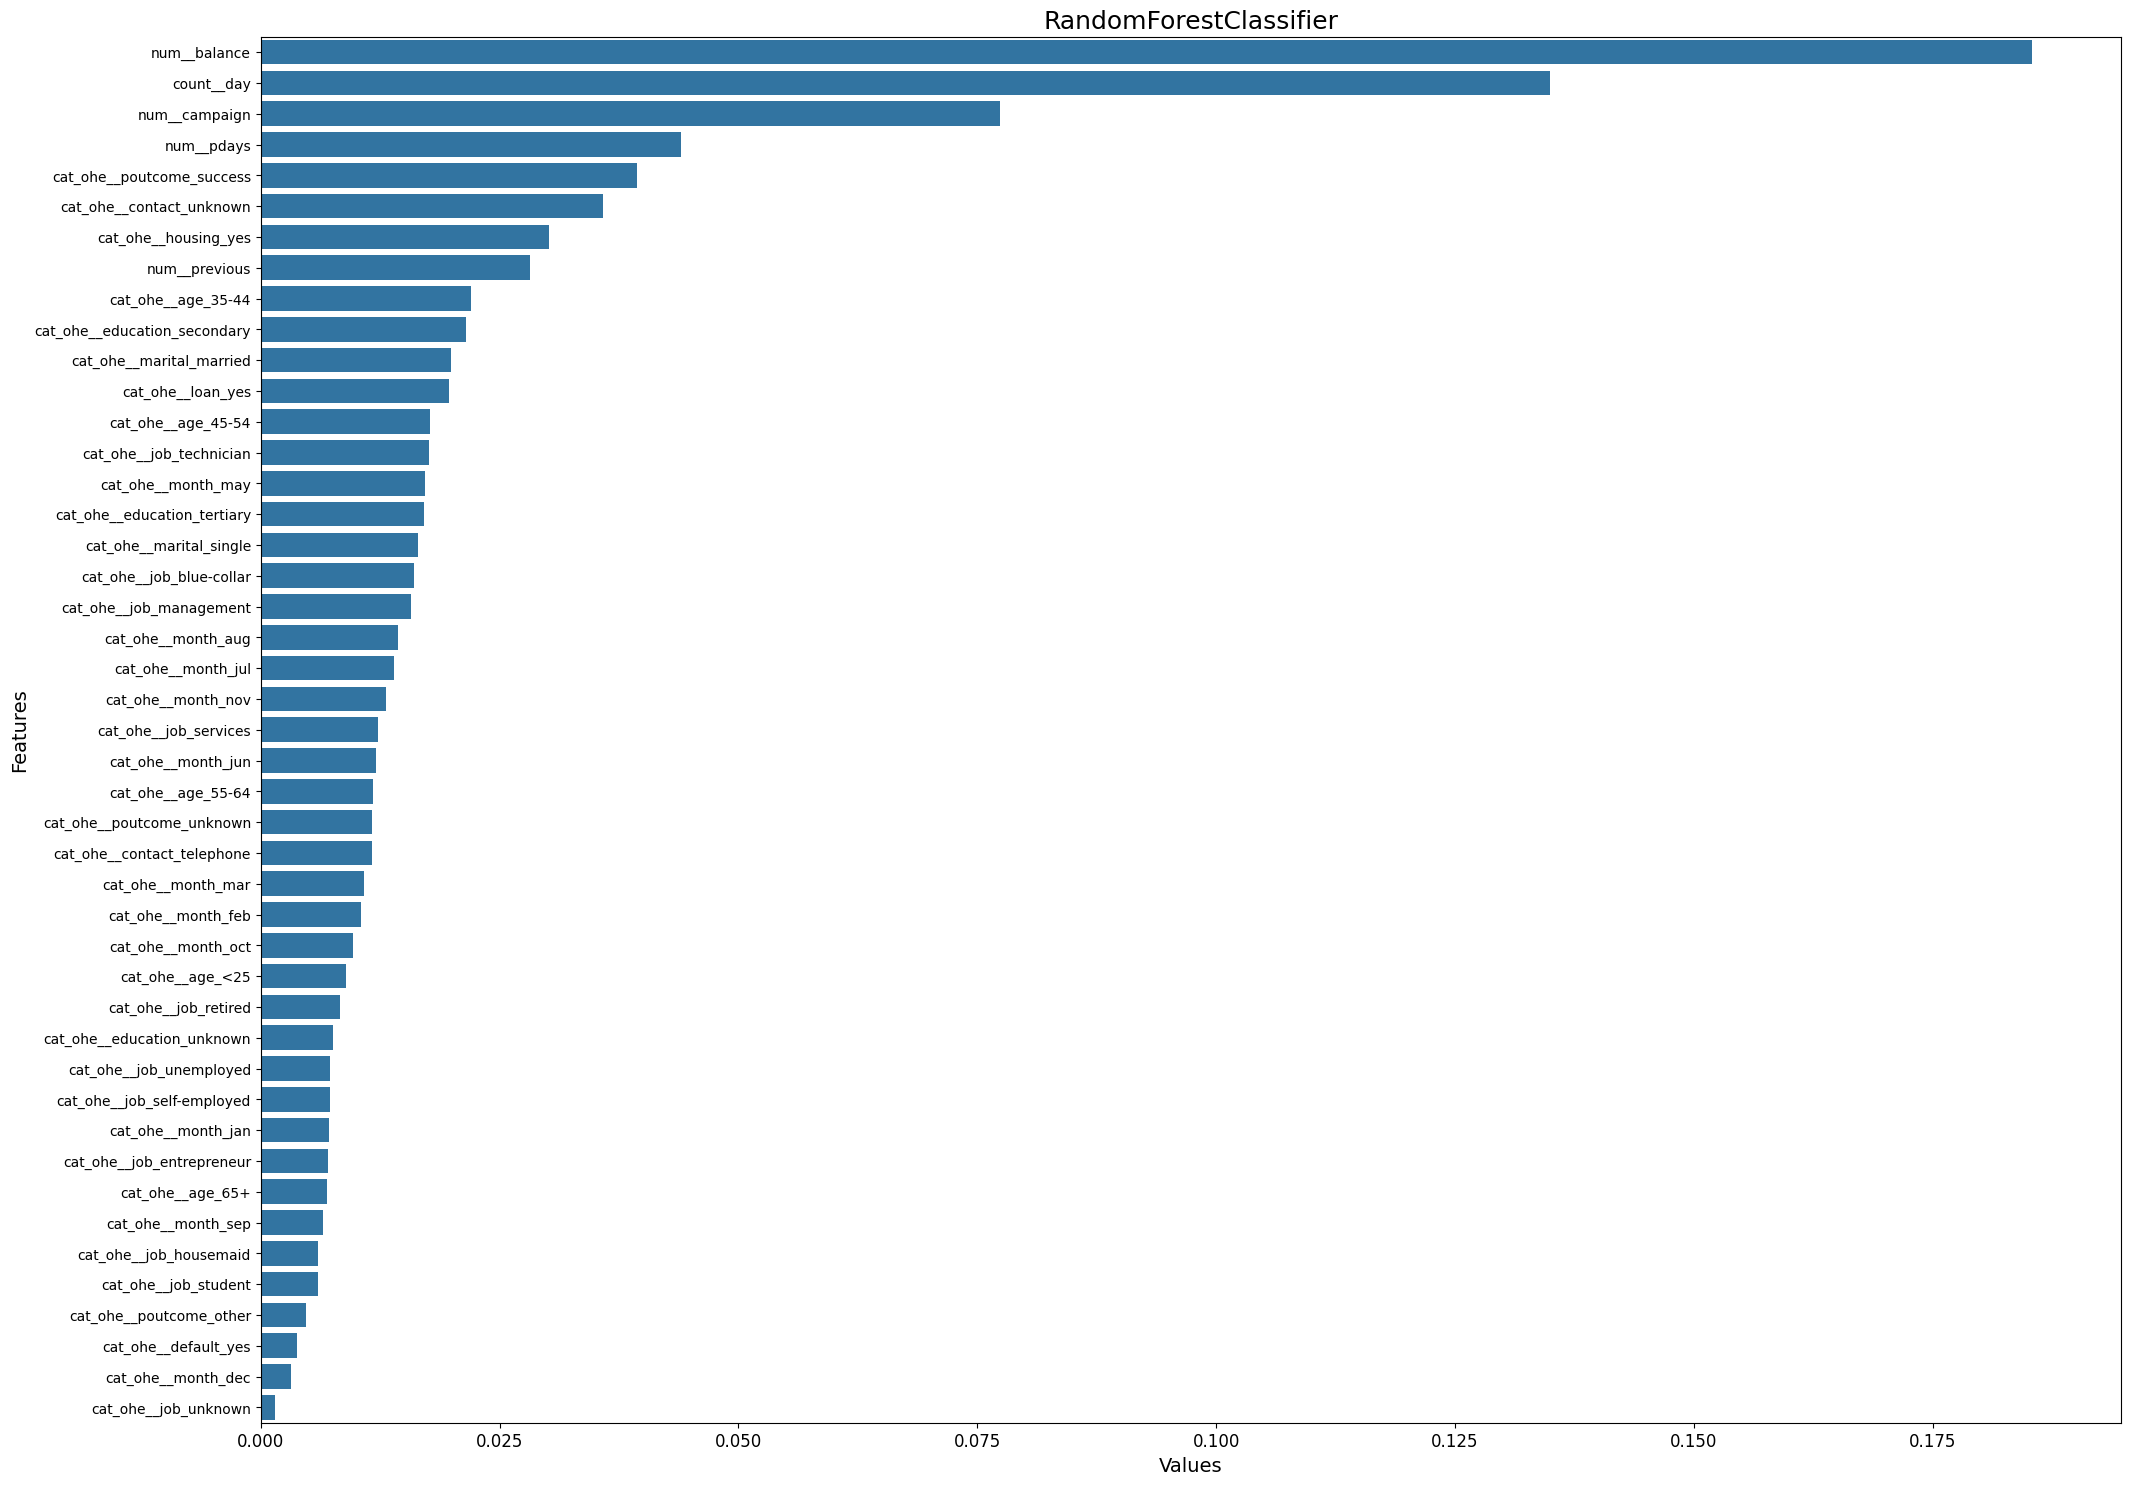

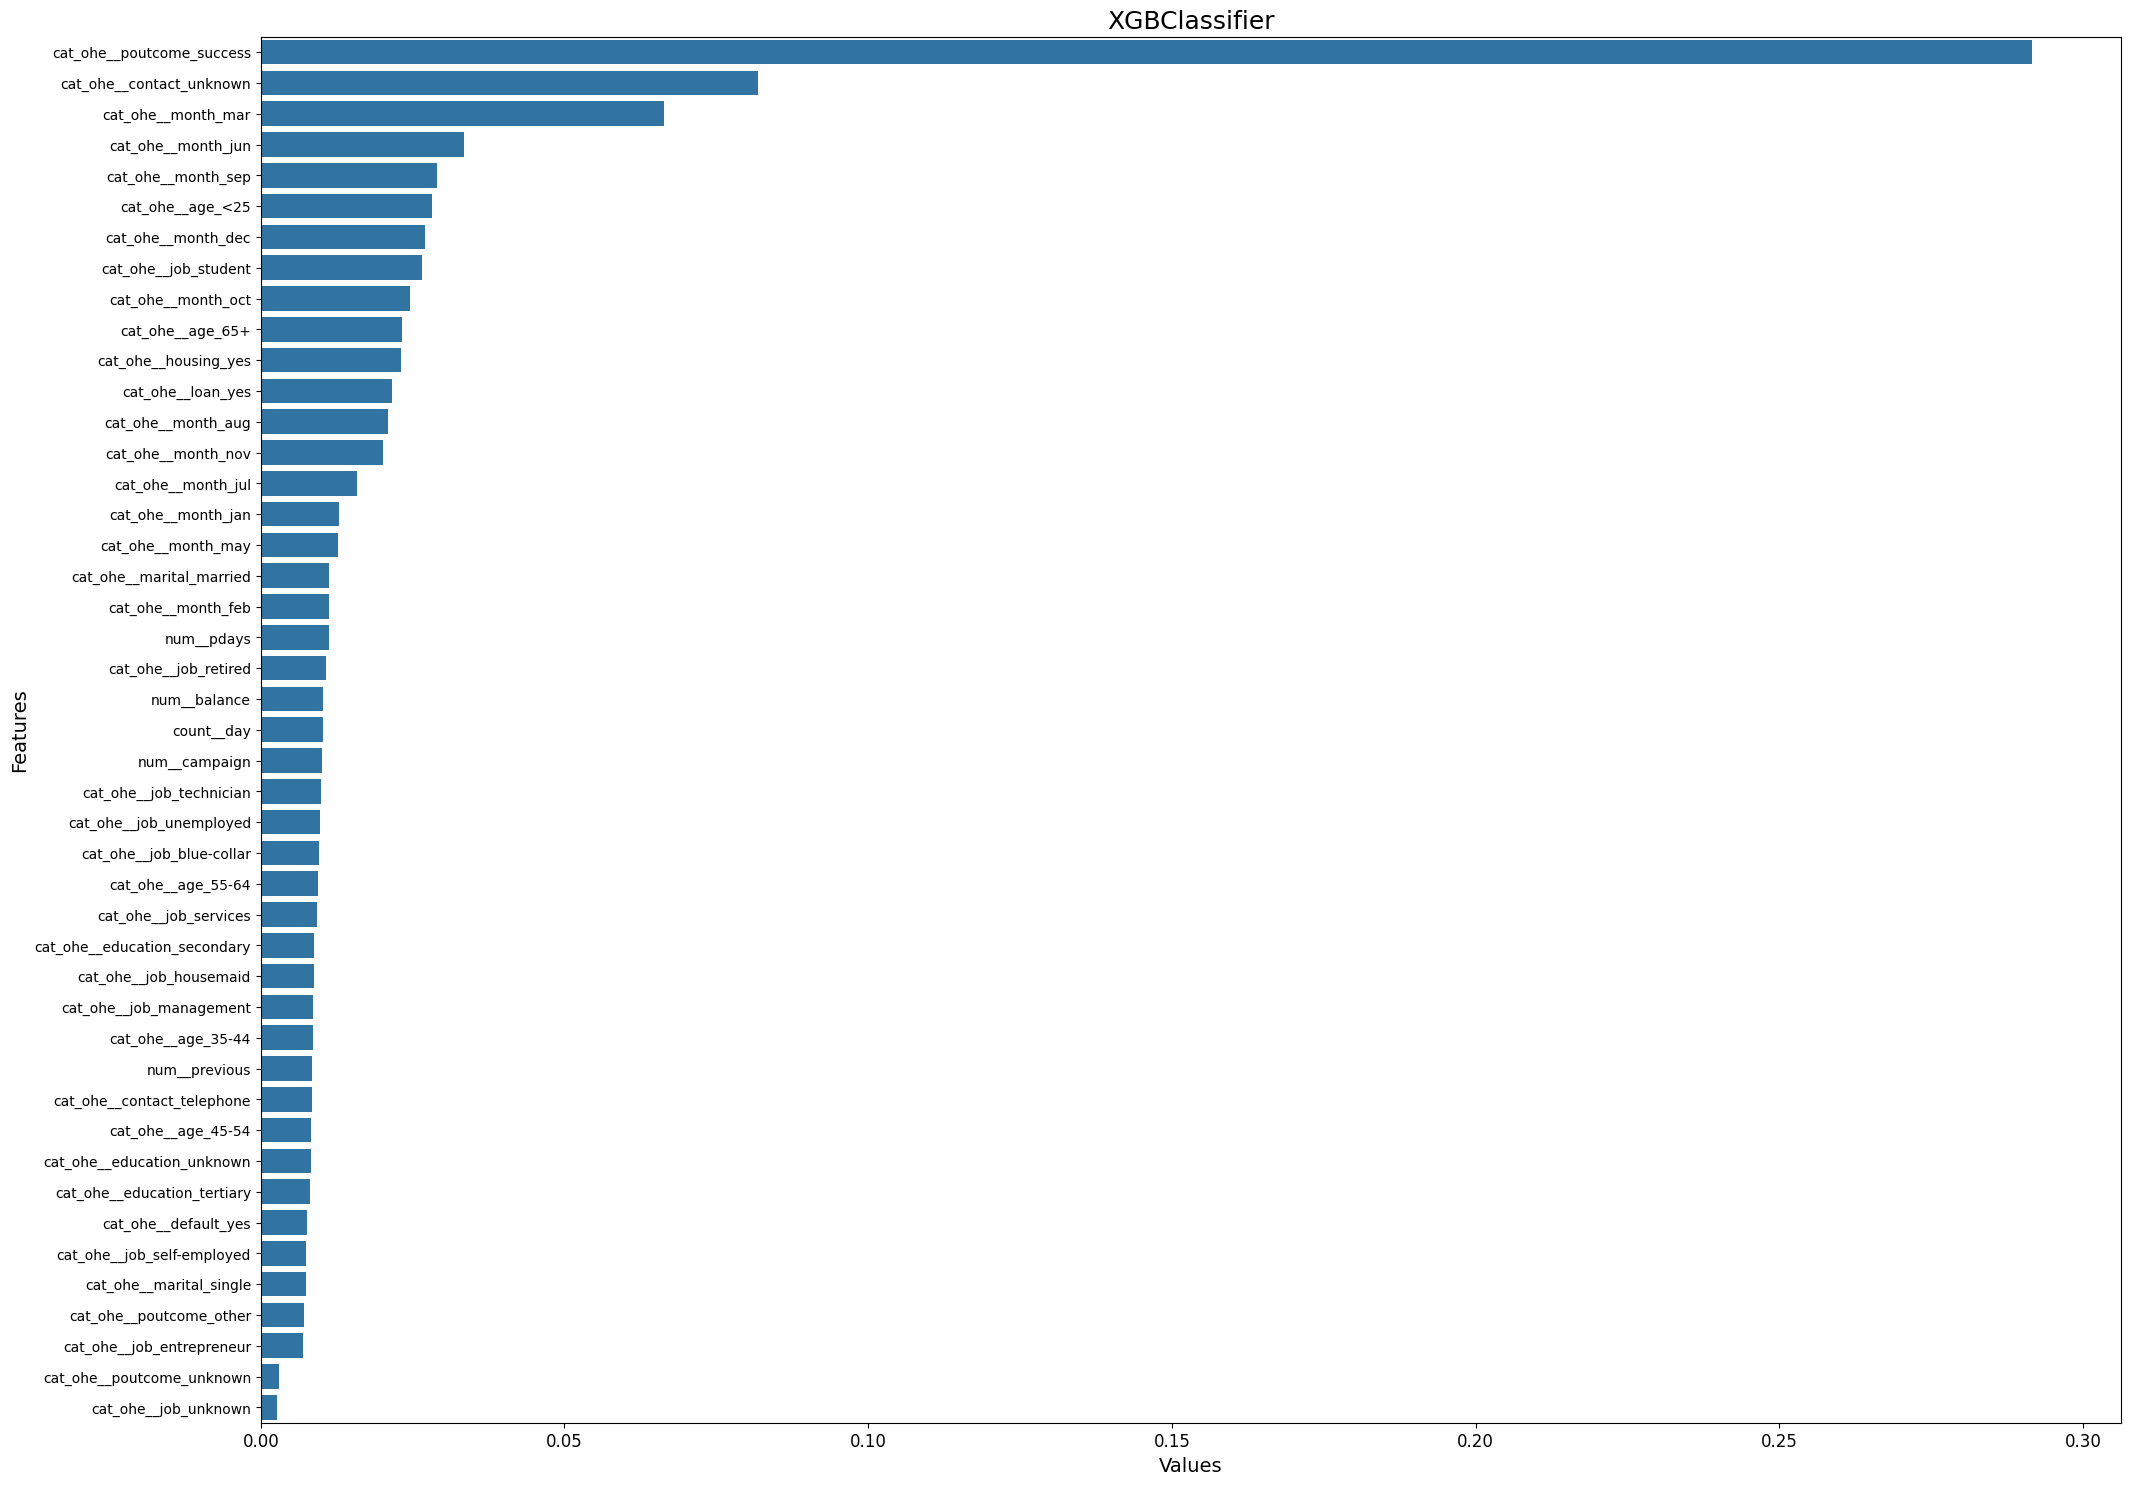

In [6]:
get_feature_importance(models_bin_count)

## Новые колонки

Создадим ряд новых колонок

In [7]:
df = data.copy()
# Были контакты или нет
df['ever_prev'] = (df['previous'] > 0).astype(int) 

# Бинаризируем признак pdays
def pdays_bucket(v):
   if v == -1:
       return 'never'
   if v <= 30:
       return 'recent'
   if v <= 60 and v > 30:
       return 'medium'
   return 'old'

df['pdays_bucket'] = df['pdays'].apply(pdays_bucket)

# Флаги для выбросов по колонкам balance, duration, campaign
df['high_balance'] = (df['balance'] > df['balance'].quantile(0.99)).astype(int)
df['many_contacts'] = (df['campaign'] > df['campaign'].quantile(0.95)).astype(int)

# Попробуем применить простое мат.преобразование к колонкам age и balance
df['age_balance'] = df['age'] * df['balance']

In [8]:
result_cross_val_new_col, result_test_new_col, list_of_models_new_col = run_experiment_pipeline(df)

In [9]:
print('')
print('Результаты на кросс-валидации')
print('')
display(result_cross_val_new_col)
print('')
print('Результаты на тестовой выборке')
print('')
display(result_test_new_col)
print('')
print('Сравнение полученного результата с baseline')
print('')
display(result_cross_val_new_col - result_cross_val_baseline)


Результаты на кросс-валидации



,roc_auc,accuracy,precision,recall,f1
LogisticRegression,0.7650,0.7080,0.7432,0.5869,0.6556
RandomForest,0.7764,0.7178,0.7345,0.6341,0.6804
XGBoost,0.7741,0.7132,0.7240,0.6381,0.6782



Результаты на тестовой выборке



,roc_auc,accuracy,precision,recall,f1
LogisticRegression,0.756931,0.693238,0.729397,0.560491,0.633886
RandomForest,0.777964,0.722347,0.745516,0.628544,0.682051
XGBoost,0.774194,0.724586,0.748597,0.630435,0.684454



Сравнение полученного результата с baseline



,roc_auc,accuracy,precision,recall,f1
LogisticRegression,0.0019,0.0024,0.0006,0.0074,0.0048
RandomForest,-0.0005,-0.0073,-0.0099,-0.0057,-0.0075
XGBoost,-0.0034,-0.0041,-0.0081,0.0014,-0.0027


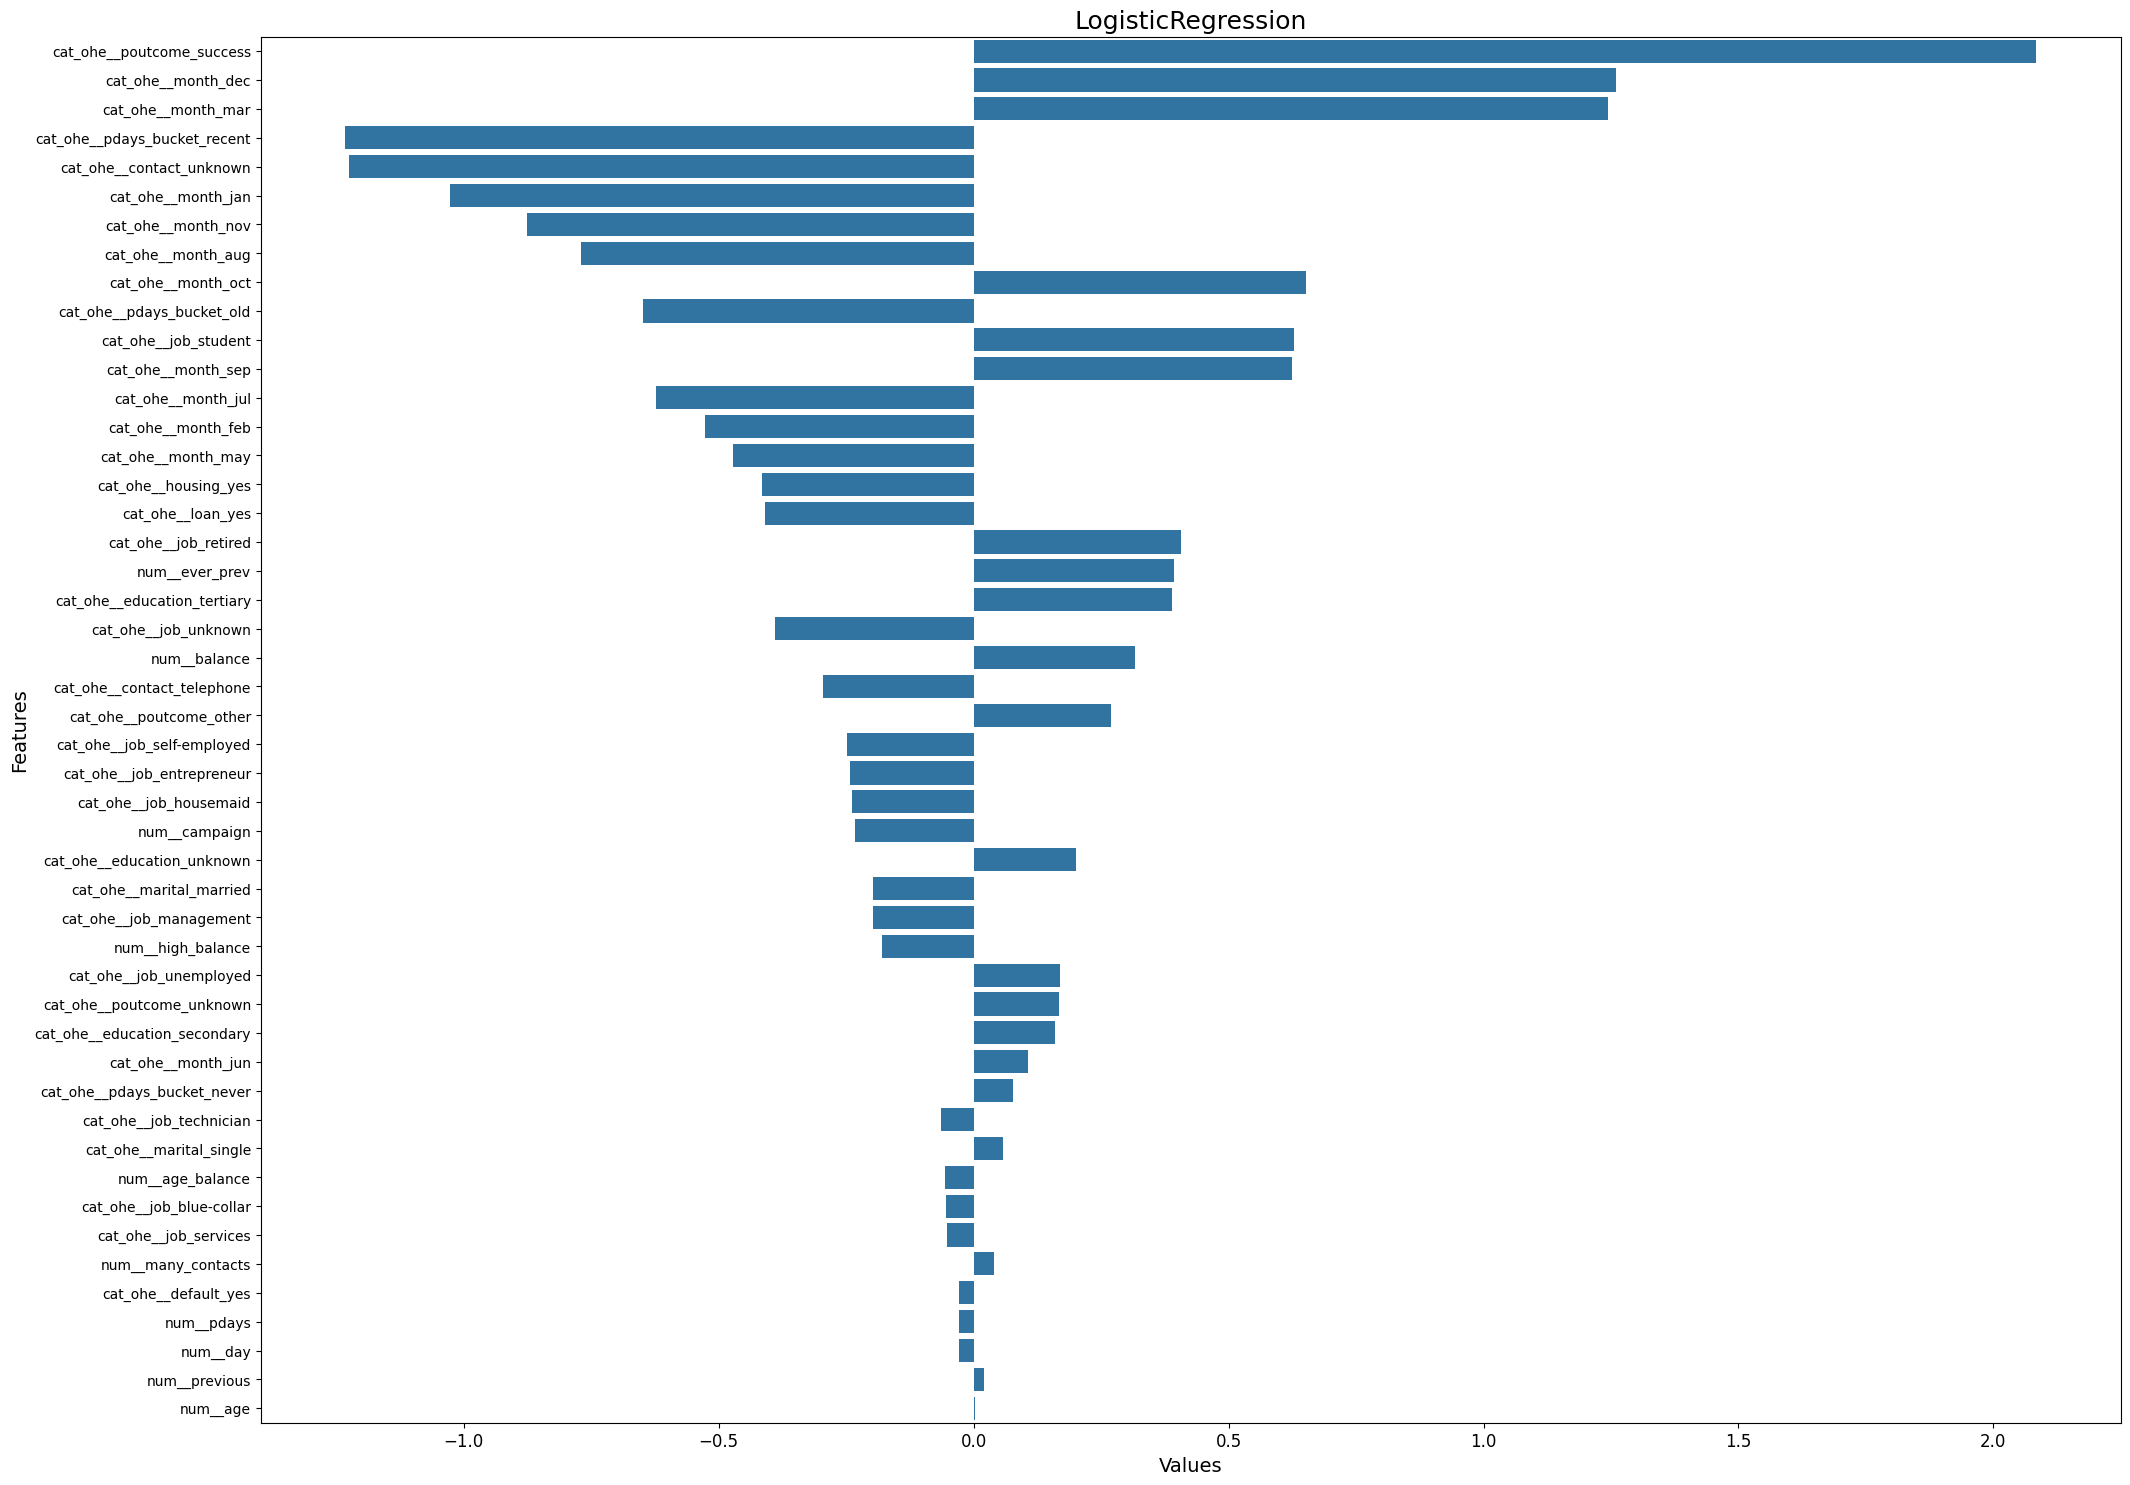

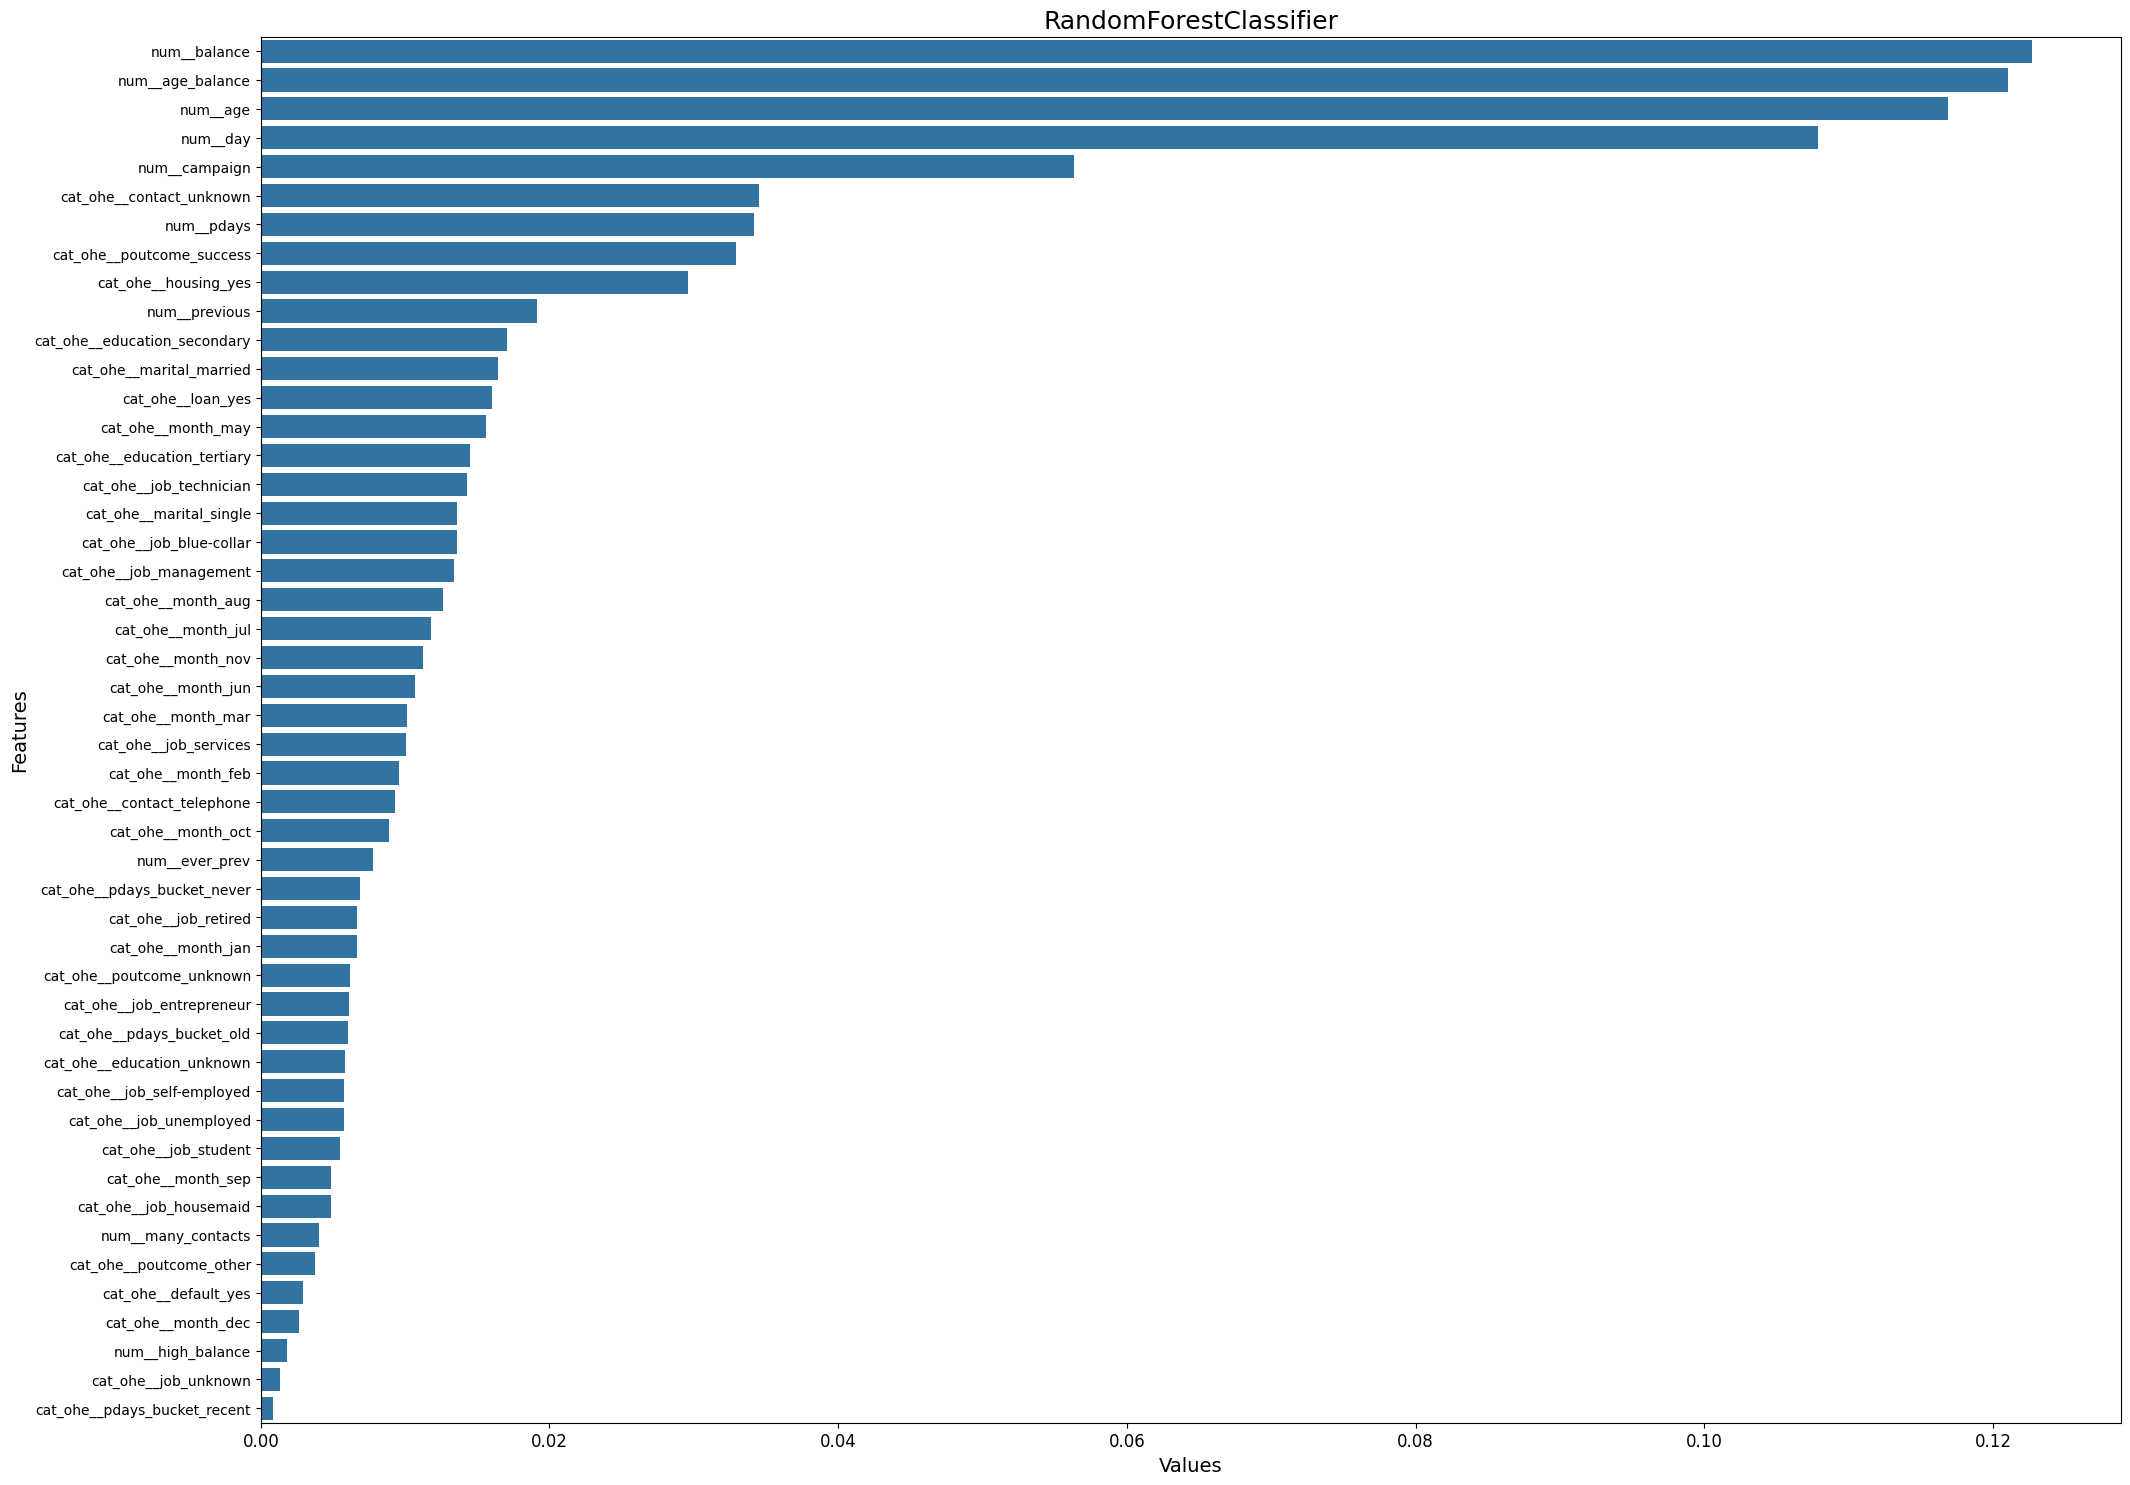

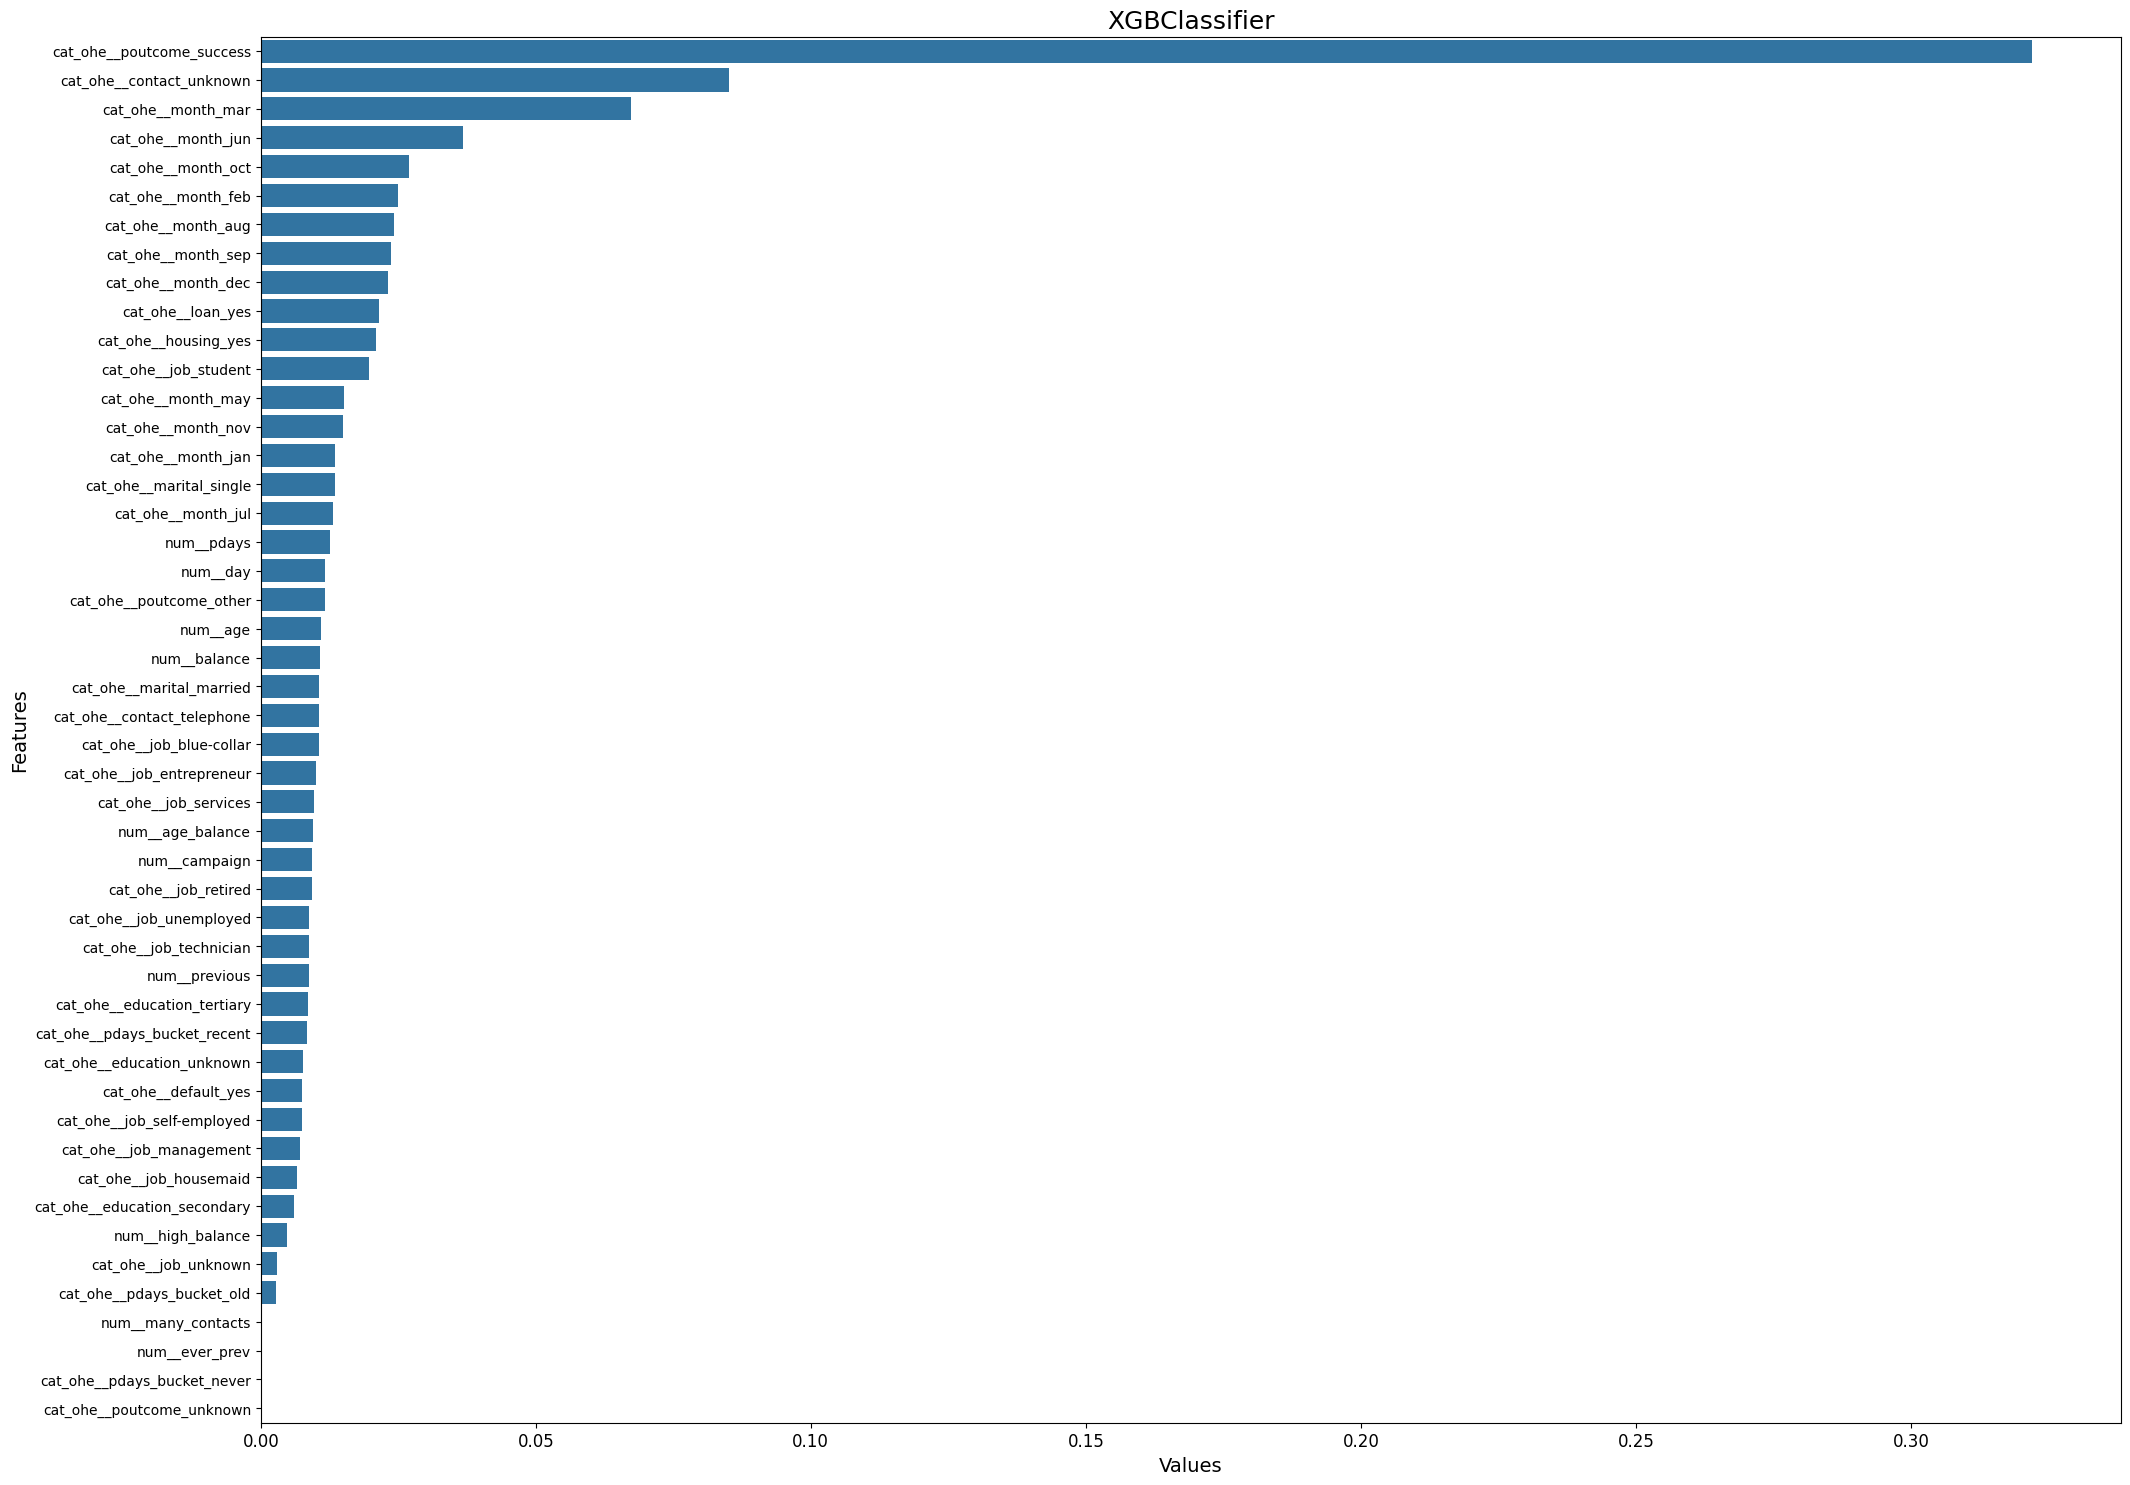

In [10]:
get_feature_importance(list_of_models_new_col)

## Лог преобразования
Прологарифмируем колонки balance, duration, pdays распределение которых сильно скошено вправо

In [11]:
df = data.copy()
df['log_balance'] = np.log1p(df['balance'].clip(lower=0))
df['log_pdays'] = np.log1p(df['pdays'].clip(lower=0))

df = df.drop(columns=['balance', 'pdays'])

In [12]:
df.head(5)

,age,job,marital,education,default,housing,loan,contact,day,month,campaign,previous,poutcome,deposit,log_balance,log_pdays
0,59,admin.,married,secondary,no,yes,no,unknown,5,may,1,0,unknown,yes,7.759614,0.0
1,56,admin.,married,secondary,no,no,no,unknown,5,may,1,0,unknown,yes,3.828641,0.0
2,41,technician,married,secondary,no,yes,no,unknown,5,may,1,0,unknown,yes,7.147559,0.0
3,55,services,married,secondary,no,yes,no,unknown,5,may,1,0,unknown,yes,7.814803,0.0
4,54,admin.,married,tertiary,no,no,no,unknown,5,may,2,0,unknown,yes,5.220356,0.0


In [13]:
result_cross_val_log, result_test_log, list_of_models_log = run_experiment_pipeline(df)

In [14]:
print('')
print('Результаты на кросс-валидации')
print('')
display(result_cross_val_log)
print('')
print('Результаты на тестовой выборке')
print('')
display(result_test_log)
print('')
print('Сравнение полученного результата с baseline')
print('')
display(result_cross_val_log - result_cross_val_baseline)


Результаты на кросс-валидации



,roc_auc,accuracy,precision,recall,f1
LogisticRegression,0.7653,0.7072,0.7372,0.5944,0.6579
RandomForest,0.7763,0.7207,0.7390,0.6351,0.6829
XGBoost,0.7792,0.7174,0.7313,0.6384,0.6816



Результаты на тестовой выборке



,roc_auc,accuracy,precision,recall,f1
LogisticRegression,0.761869,0.698164,0.731325,0.573724,0.643008
RandomForest,0.778964,0.721003,0.743561,0.627599,0.680677
XGBoost,0.769168,0.719212,0.744054,0.620983,0.676971



Сравнение полученного результата с baseline



,roc_auc,accuracy,precision,recall,f1
LogisticRegression,0.0022,0.0016,-0.0054,0.0149,0.0071
RandomForest,-0.0006,-0.0044,-0.0054,-0.0047,-0.0050
XGBoost,0.0017,0.0001,-0.0008,0.0017,0.0007


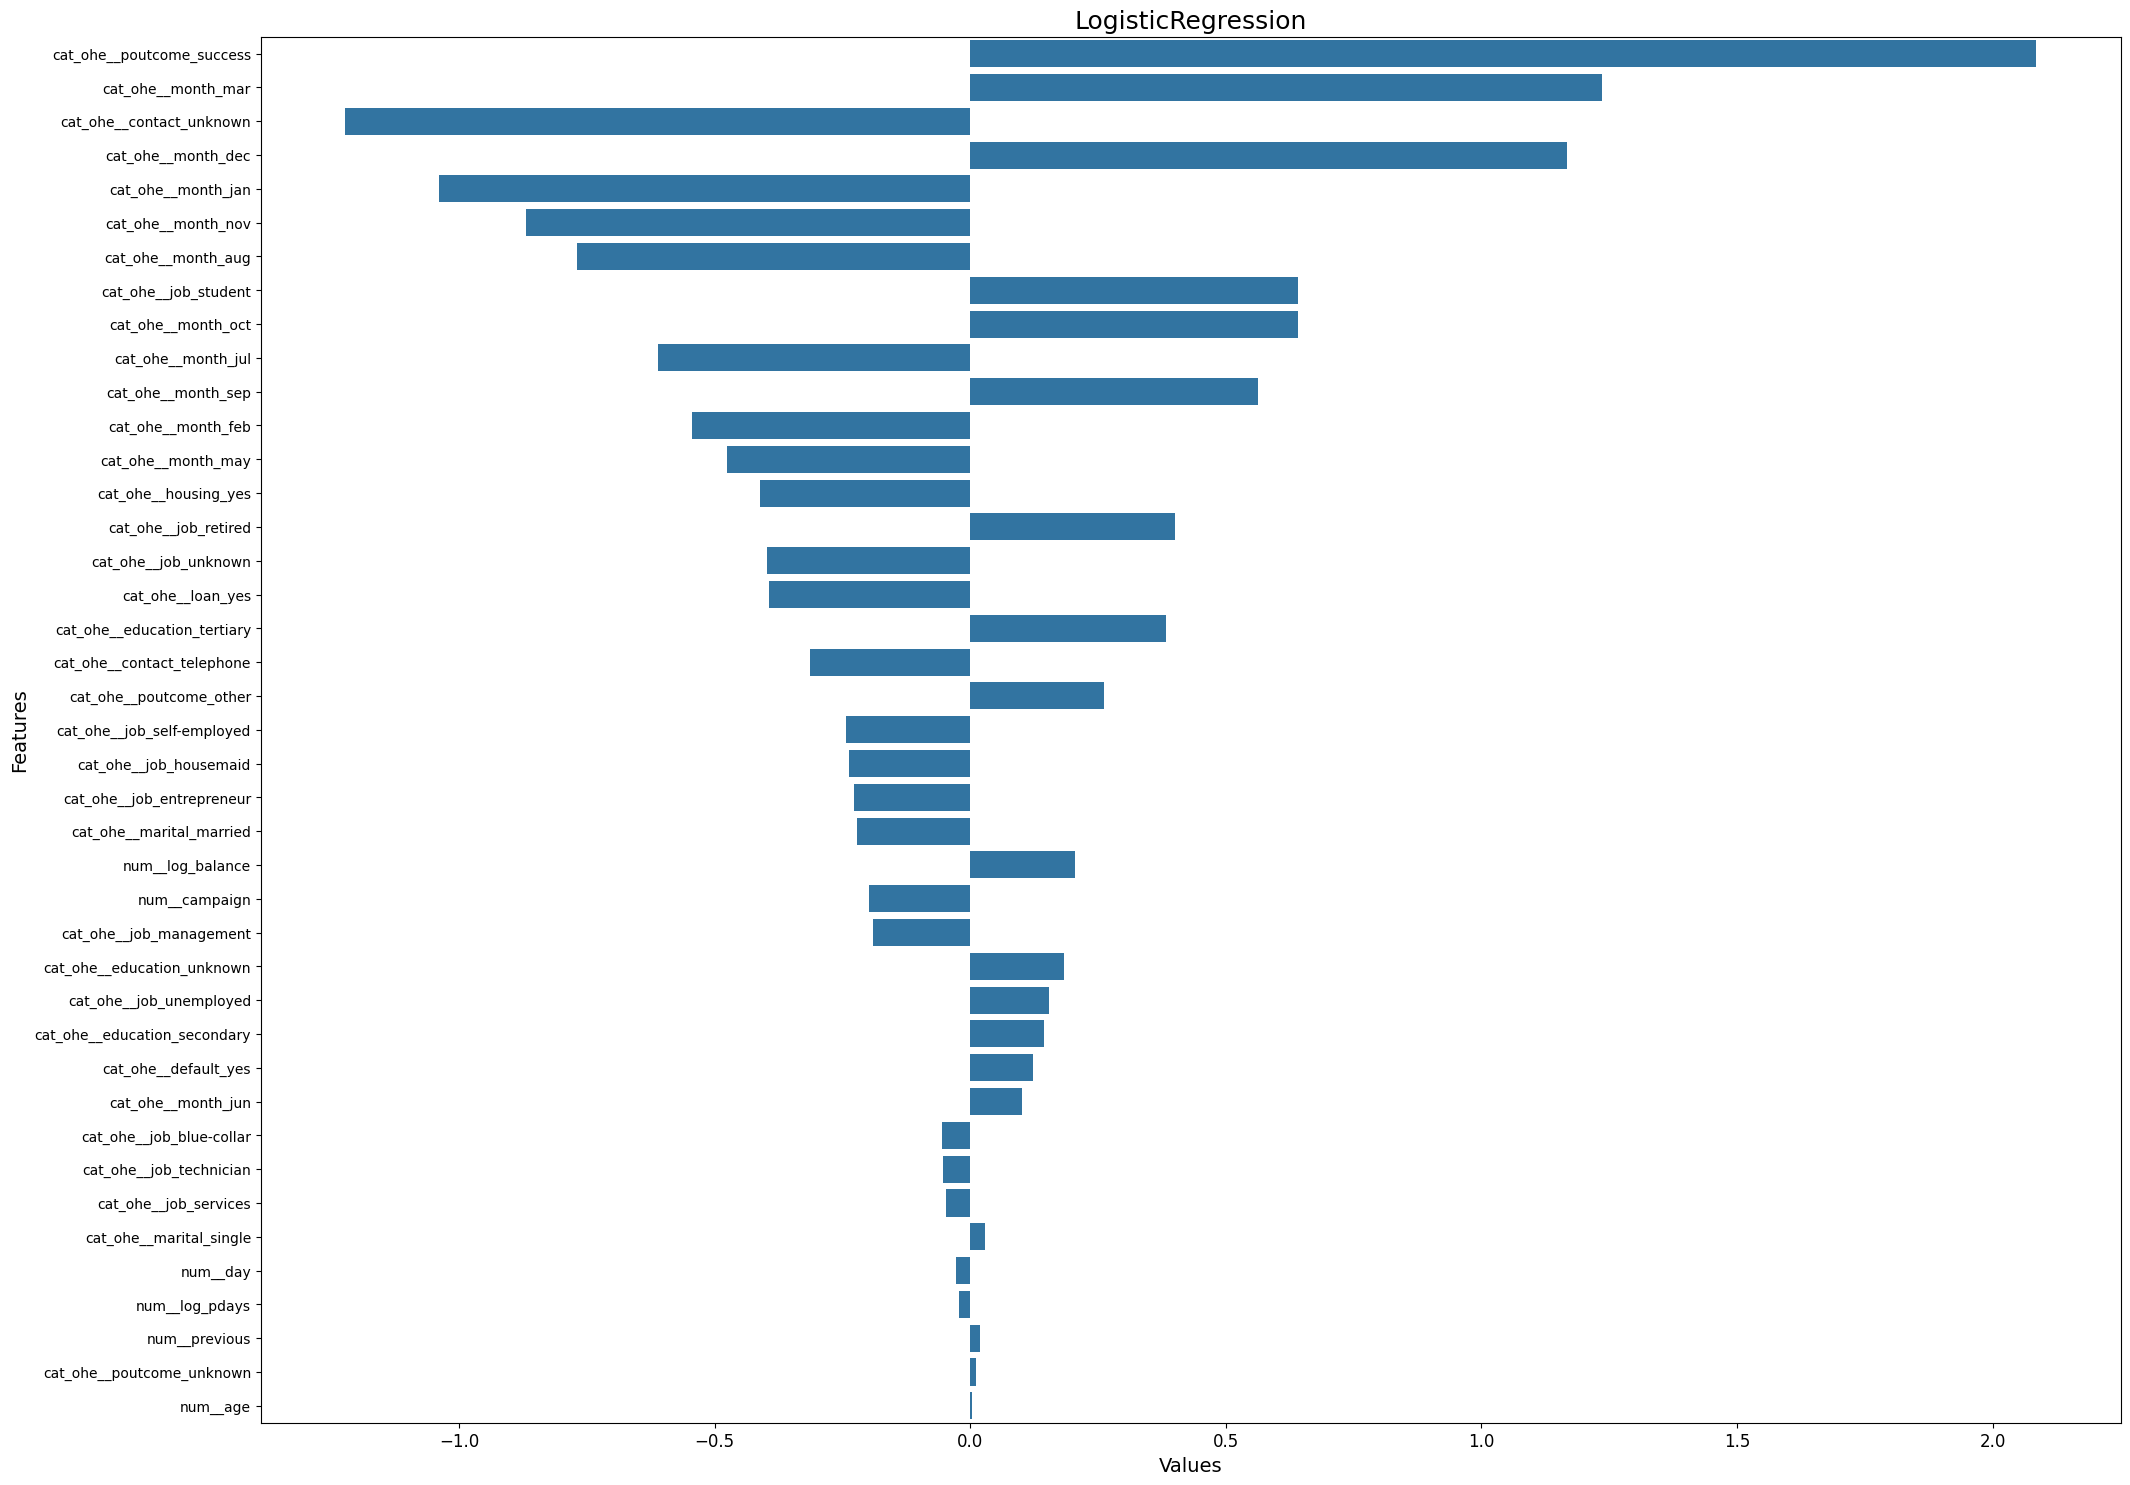

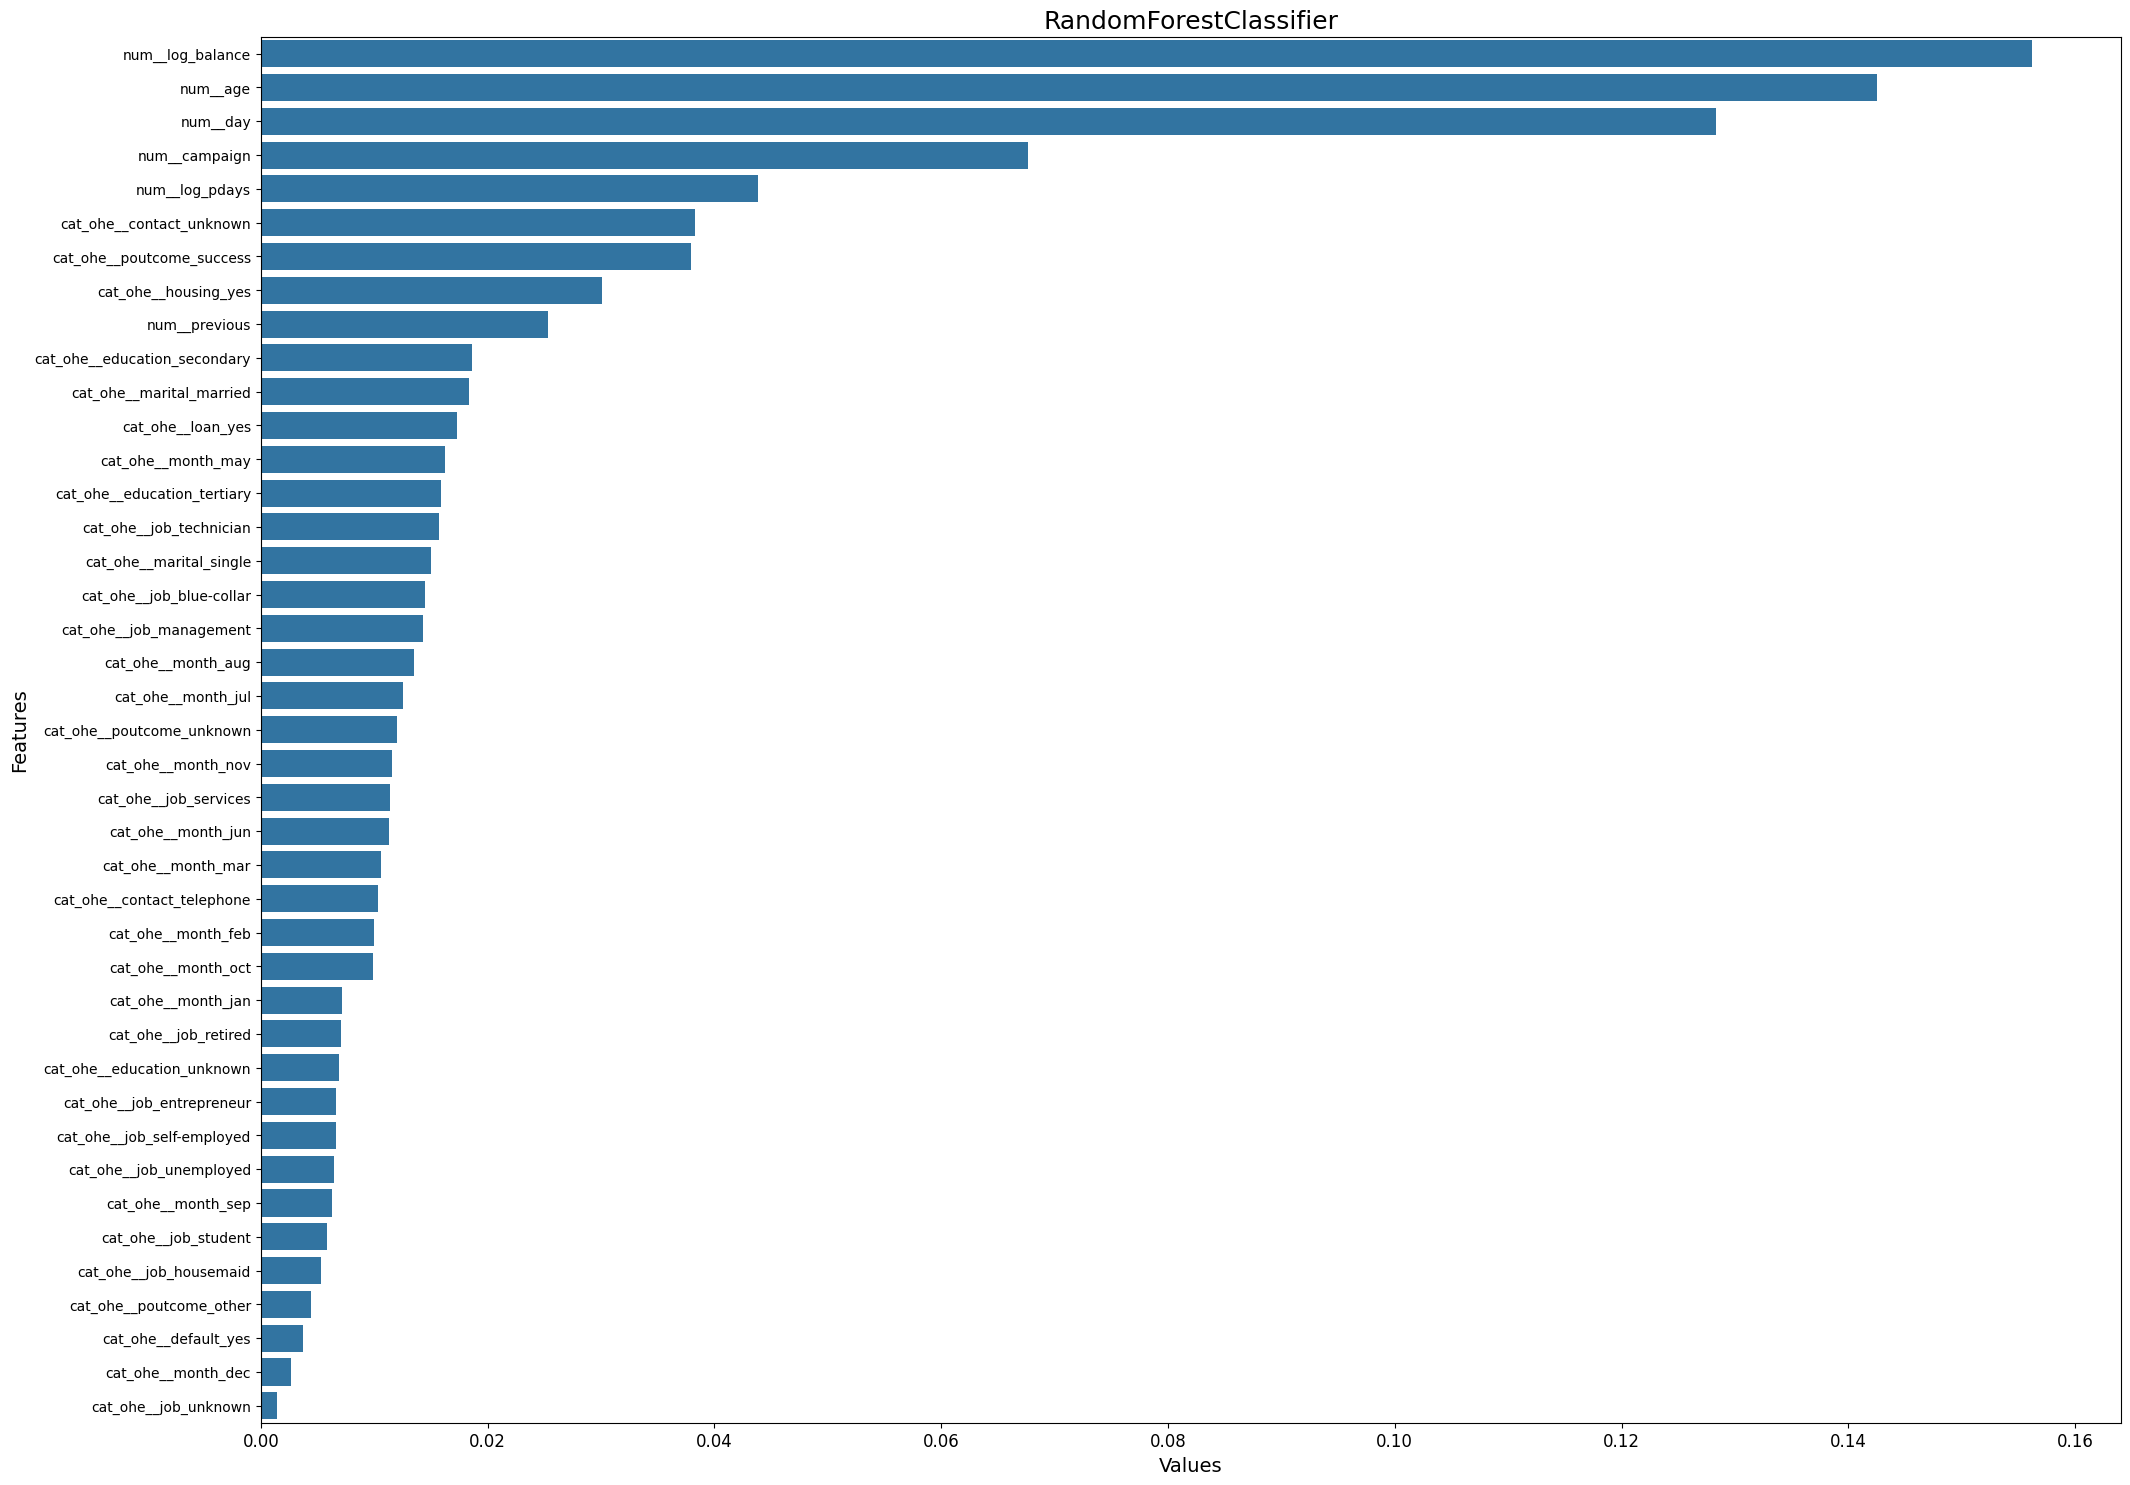

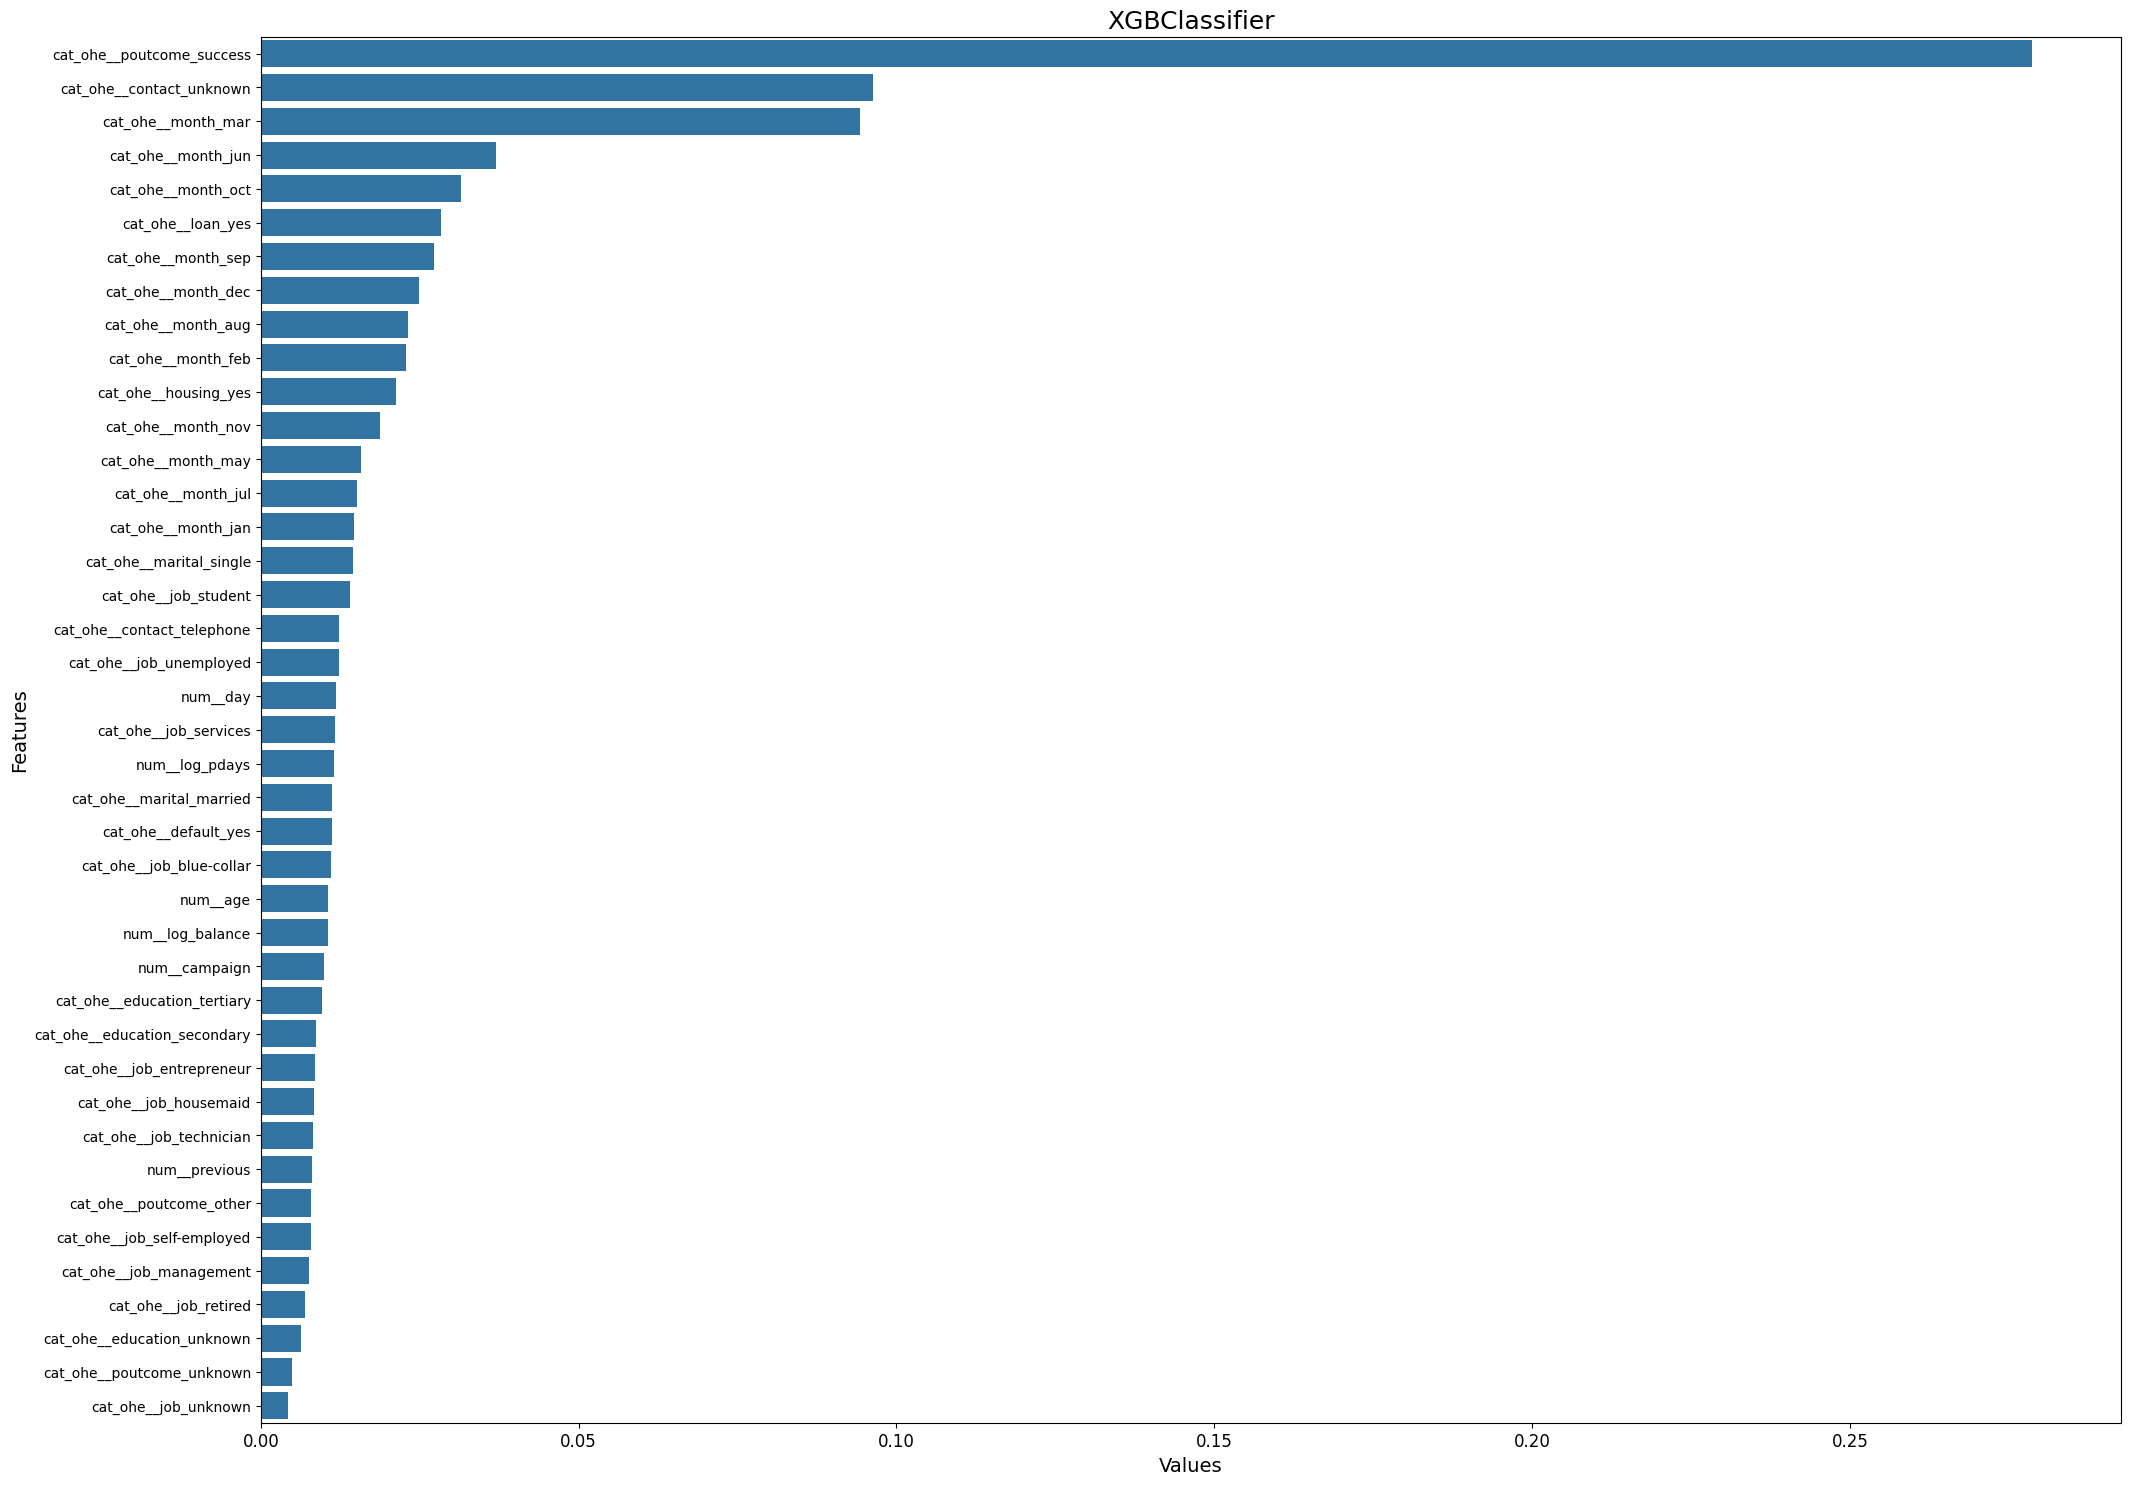

In [15]:
get_feature_importance(list_of_models_log)

## Target Encoding
Target Encoding это способ кодирования категориальных признаков, при котором каждой категории присваивается статистика по целевой переменной. В задаче классификации это вероятность класса. Создадим новые колонки с помощью TargetEncoder по колонкам duration (предварительно проведя бинаризацию), poutcome, education, contact. оригинальные колонки будут удалены из датасета (кроме цифровой колонки duration)

In [17]:
df = data.copy()

In [18]:
result_cross_val_te, result_test_te, list_of_models_te = run_experiment_pipeline(df, target_cols=['poutcome', 'education', 'contact'])

In [19]:
print('')
print('Результаты на кросс-валидации')
print('')
display(result_cross_val_te)
print('')
print('Результаты на тестовой выборке')
print('')
display(result_test_te)
print('')
print('Сравнение полученного результата с baseline')
print('')
display(result_cross_val_te - result_cross_val_baseline)


Результаты на кросс-валидации



,roc_auc,accuracy,precision,recall,f1
LogisticRegression,0.7624,0.7077,0.7427,0.5864,0.6551
RandomForest,0.7783,0.7211,0.7378,0.6393,0.6847
XGBoost,0.7787,0.7163,0.7300,0.6372,0.6803



Результаты на тестовой выборке



,roc_auc,accuracy,precision,recall,f1
LogisticRegression,0.757025,0.693238,0.734003,0.552930,0.630728
RandomForest,0.776659,0.725034,0.747768,0.633270,0.685773
XGBoost,0.772904,0.712494,0.729075,0.625709,0.673449



Сравнение полученного результата с baseline



,roc_auc,accuracy,precision,recall,f1
LogisticRegression,-0.0007,0.0021,0.0001,0.0069,0.0043
RandomForest,0.0014,-0.0040,-0.0066,-0.0005,-0.0032
XGBoost,0.0012,-0.0010,-0.0021,0.0005,-0.0006


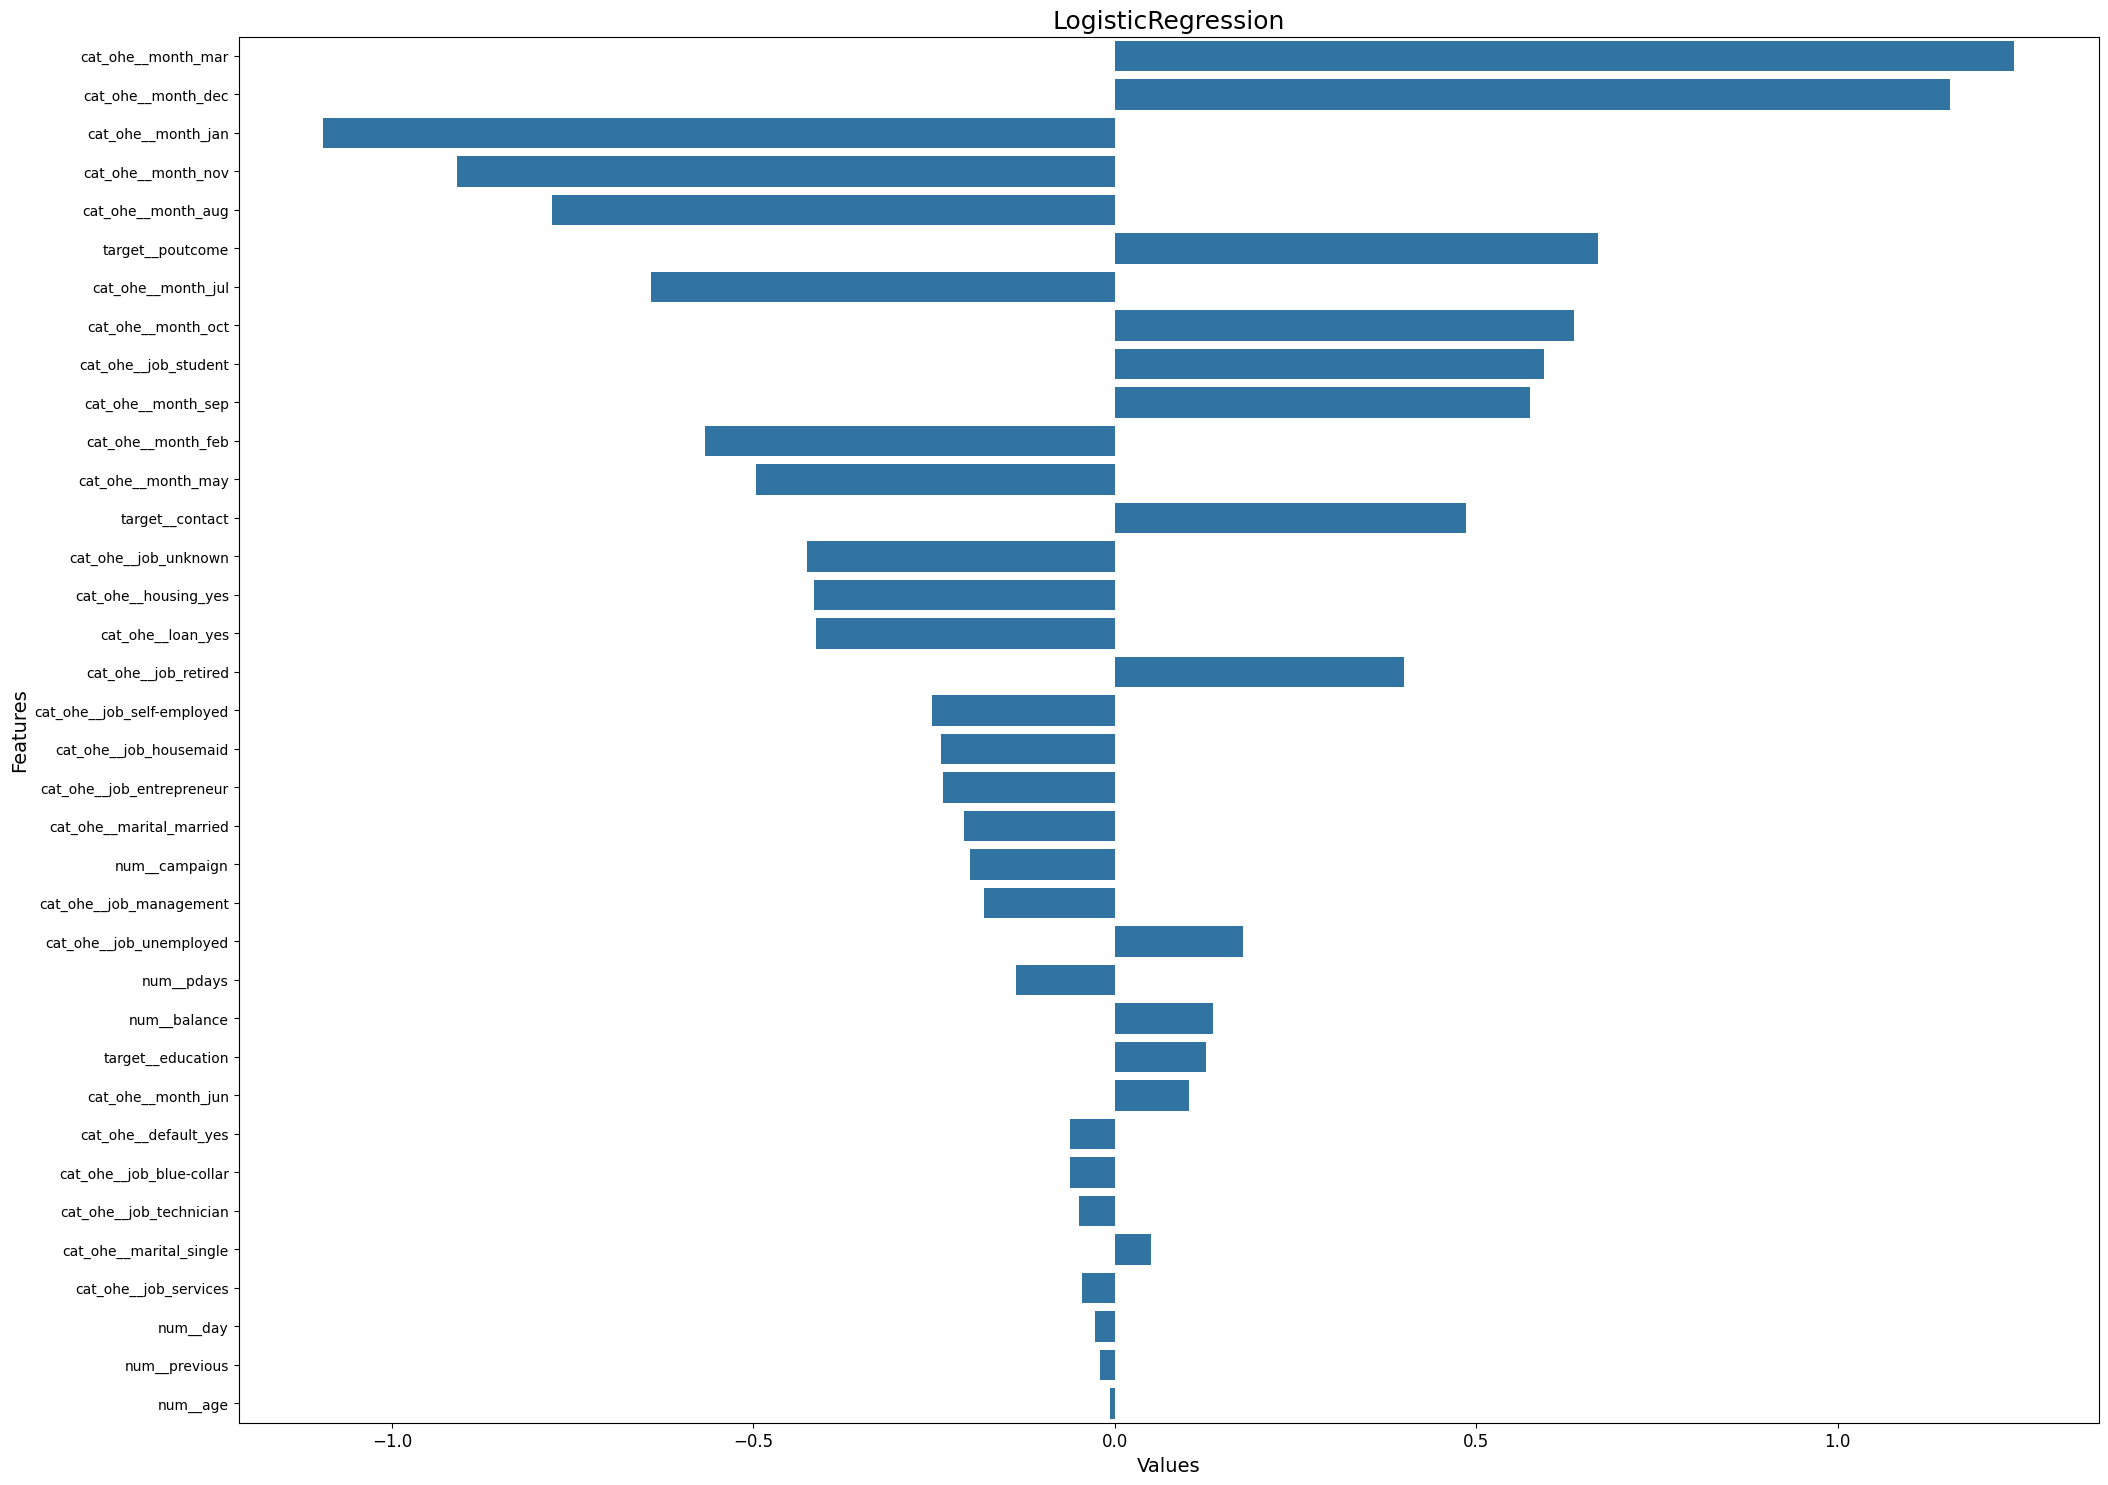

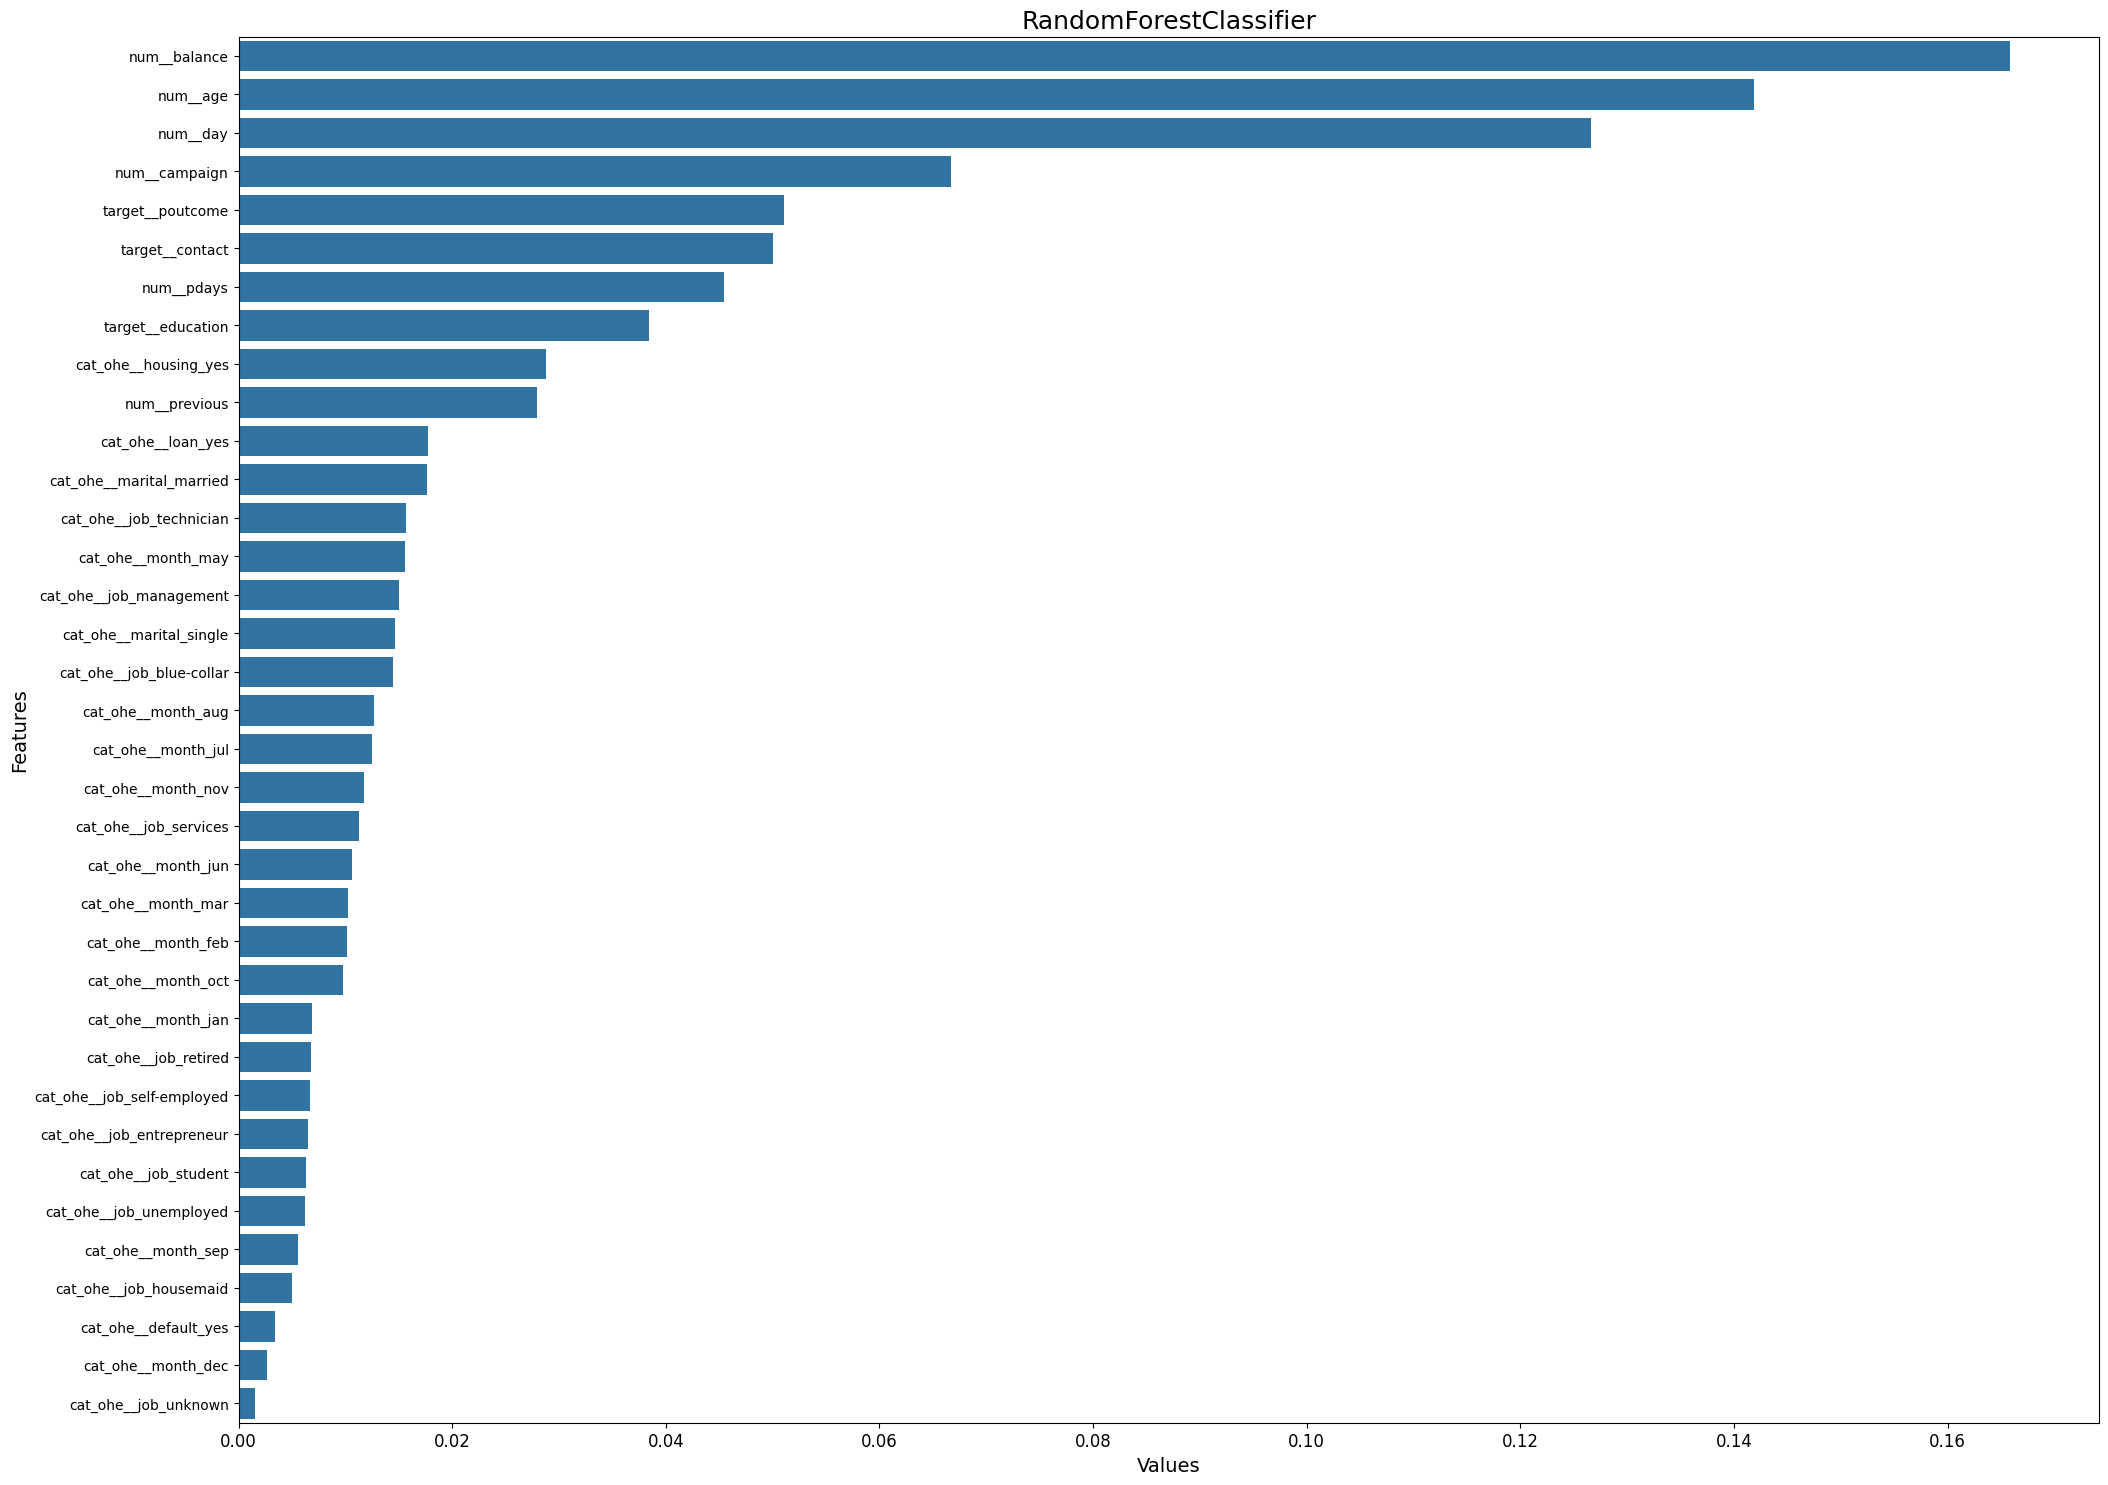

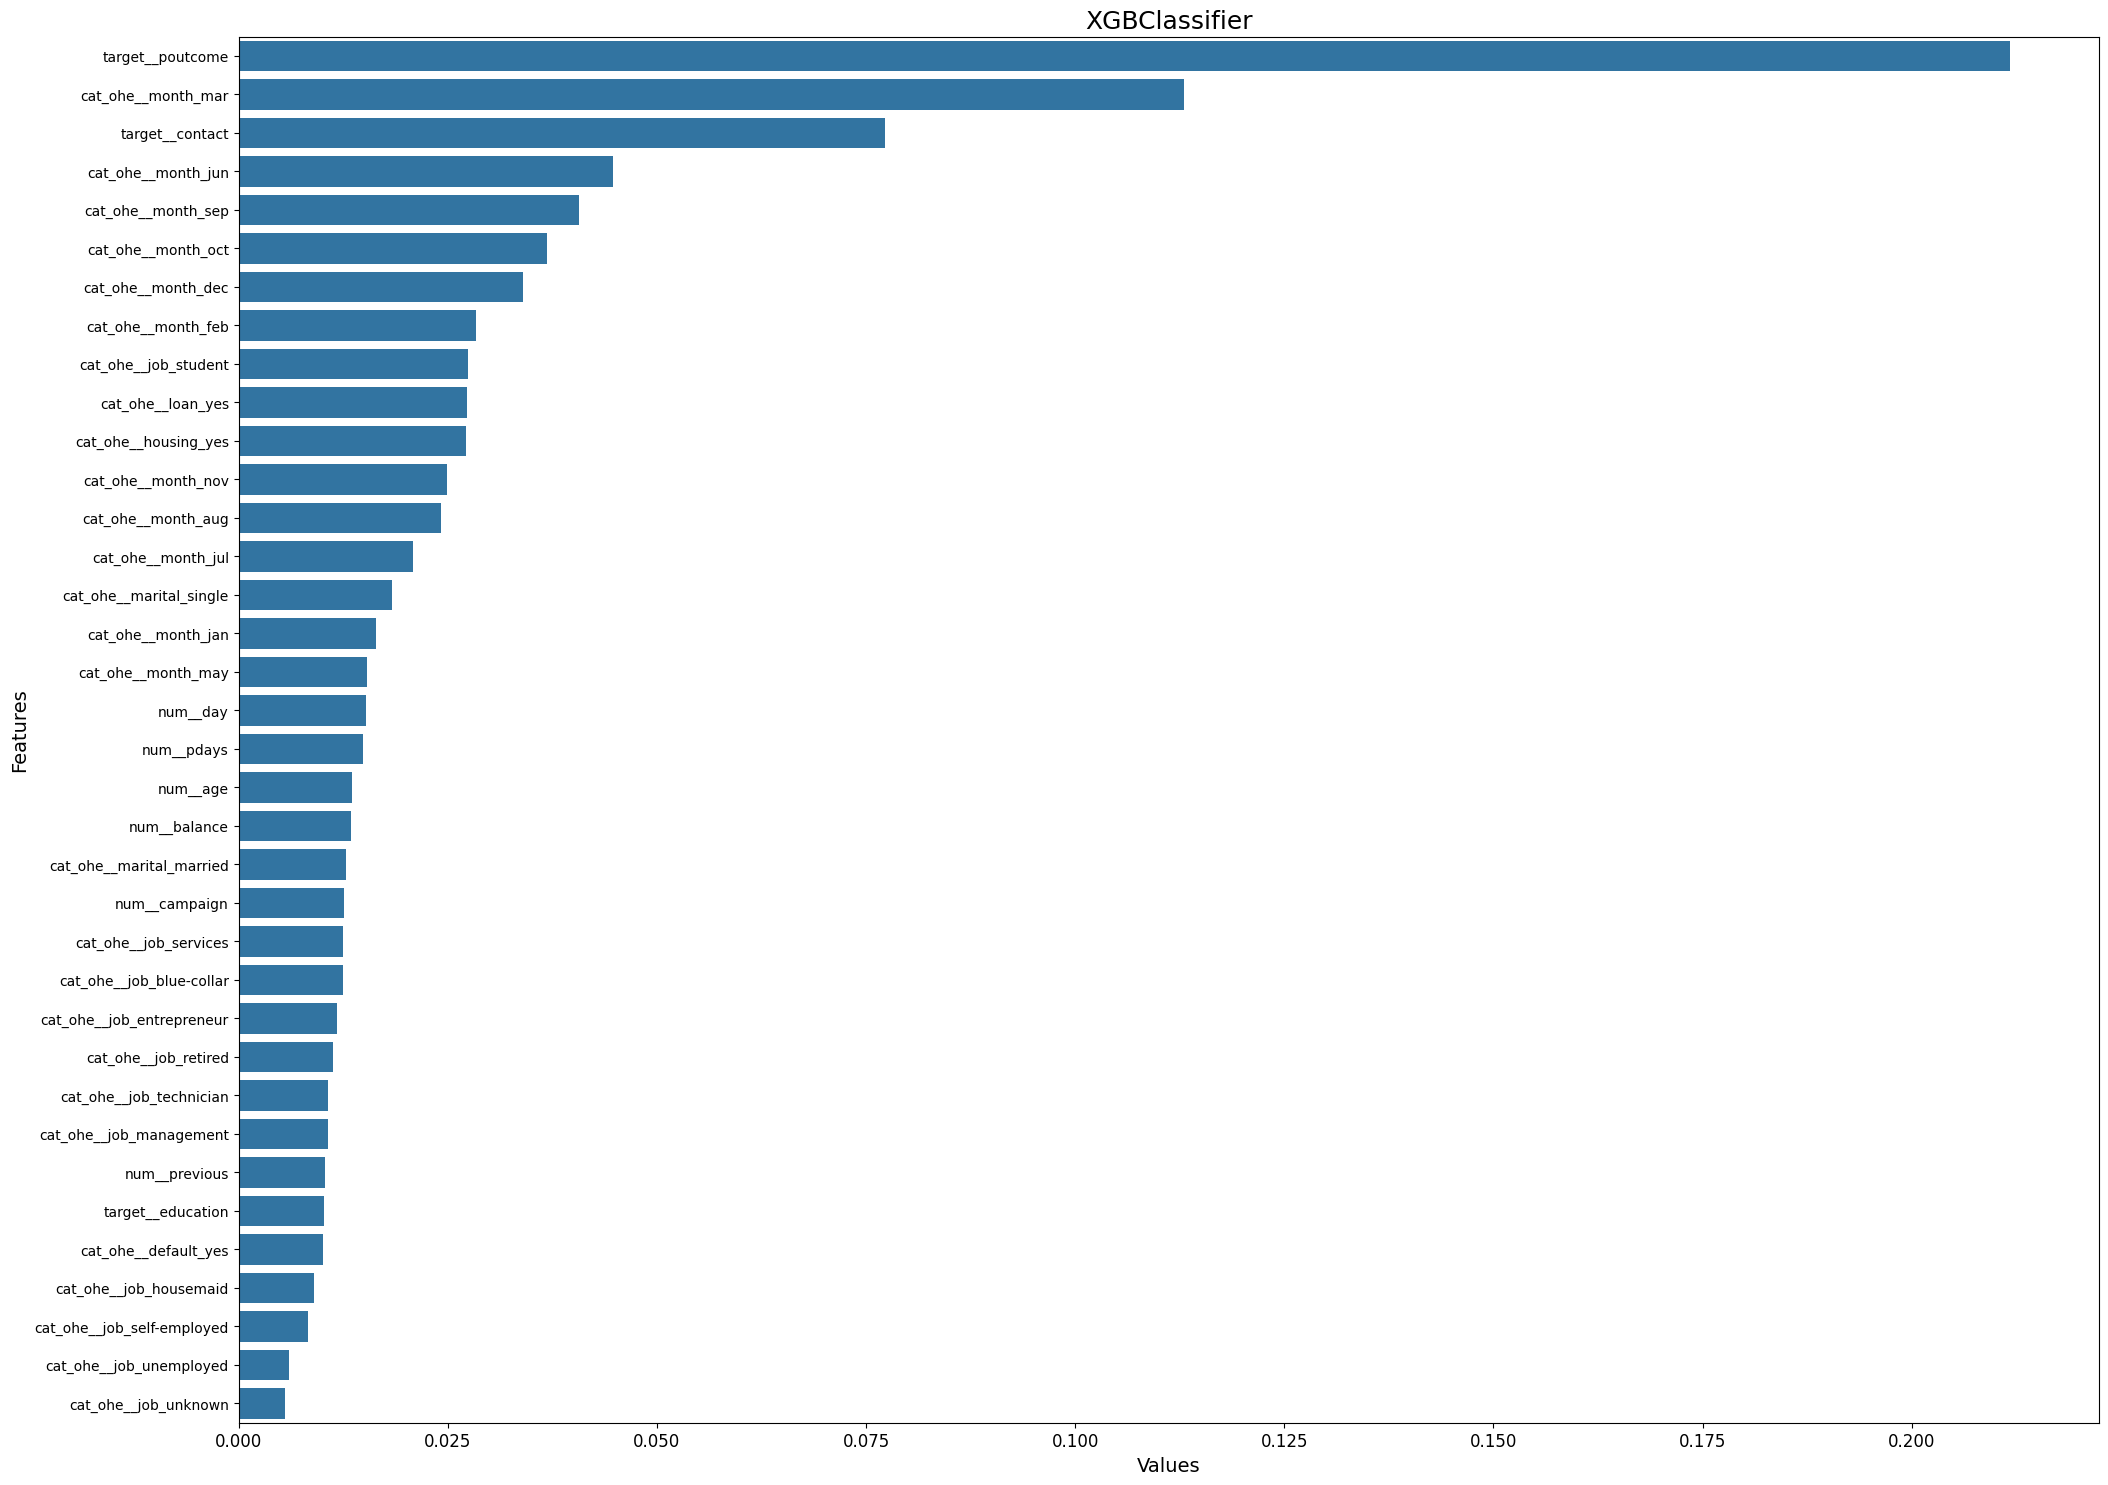

In [20]:
get_feature_importance(list_of_models_te)

## Обработка выбросов
Так как в датасете присутствуют выбросы попробуем заменить их экстремальные значения на 1-ый или 99-ый квантиль

In [4]:
df = data.copy()

In [6]:
clip_cols = df.select_dtypes(include='number').columns.to_list()

In [8]:
result_cross_val_o, result_test_o, list_of_models_o = run_experiment_pipeline(df, clip_cols=clip_cols)

In [9]:
print('')
print('Результаты на кросс-валидации')
print('')
display(result_cross_val_o)
print('')
print('Результаты на тестовой выборке')
print('')
display(result_test_o)
print('')
print('Сравнение полученного результата с baseline')
print('')
display(result_cross_val_o - result_cross_val_baseline)


Результаты на кросс-валидации



,roc_auc,accuracy,precision,recall,f1
LogisticRegression,0.7644,0.7066,0.7416,0.5847,0.6536
RandomForest,0.7759,0.7251,0.7444,0.6403,0.6881
XGBoost,0.7806,0.7234,0.7385,0.6443,0.6881



Результаты на тестовой выборке



,roc_auc,accuracy,precision,recall,f1
LogisticRegression,0.758410,0.694581,0.730392,0.563327,0.636073
RandomForest,0.777473,0.721899,0.748578,0.621928,0.679401
XGBoost,0.772599,0.717868,0.735683,0.631380,0.679552



Сравнение полученного результата с baseline



,roc_auc,accuracy,precision,recall,f1
LogisticRegression,0.0013,0.0010,-0.0010,0.0052,0.0028
RandomForest,-0.0010,0.0000,0.0000,0.0005,0.0002
XGBoost,0.0031,0.0061,0.0064,0.0076,0.0072


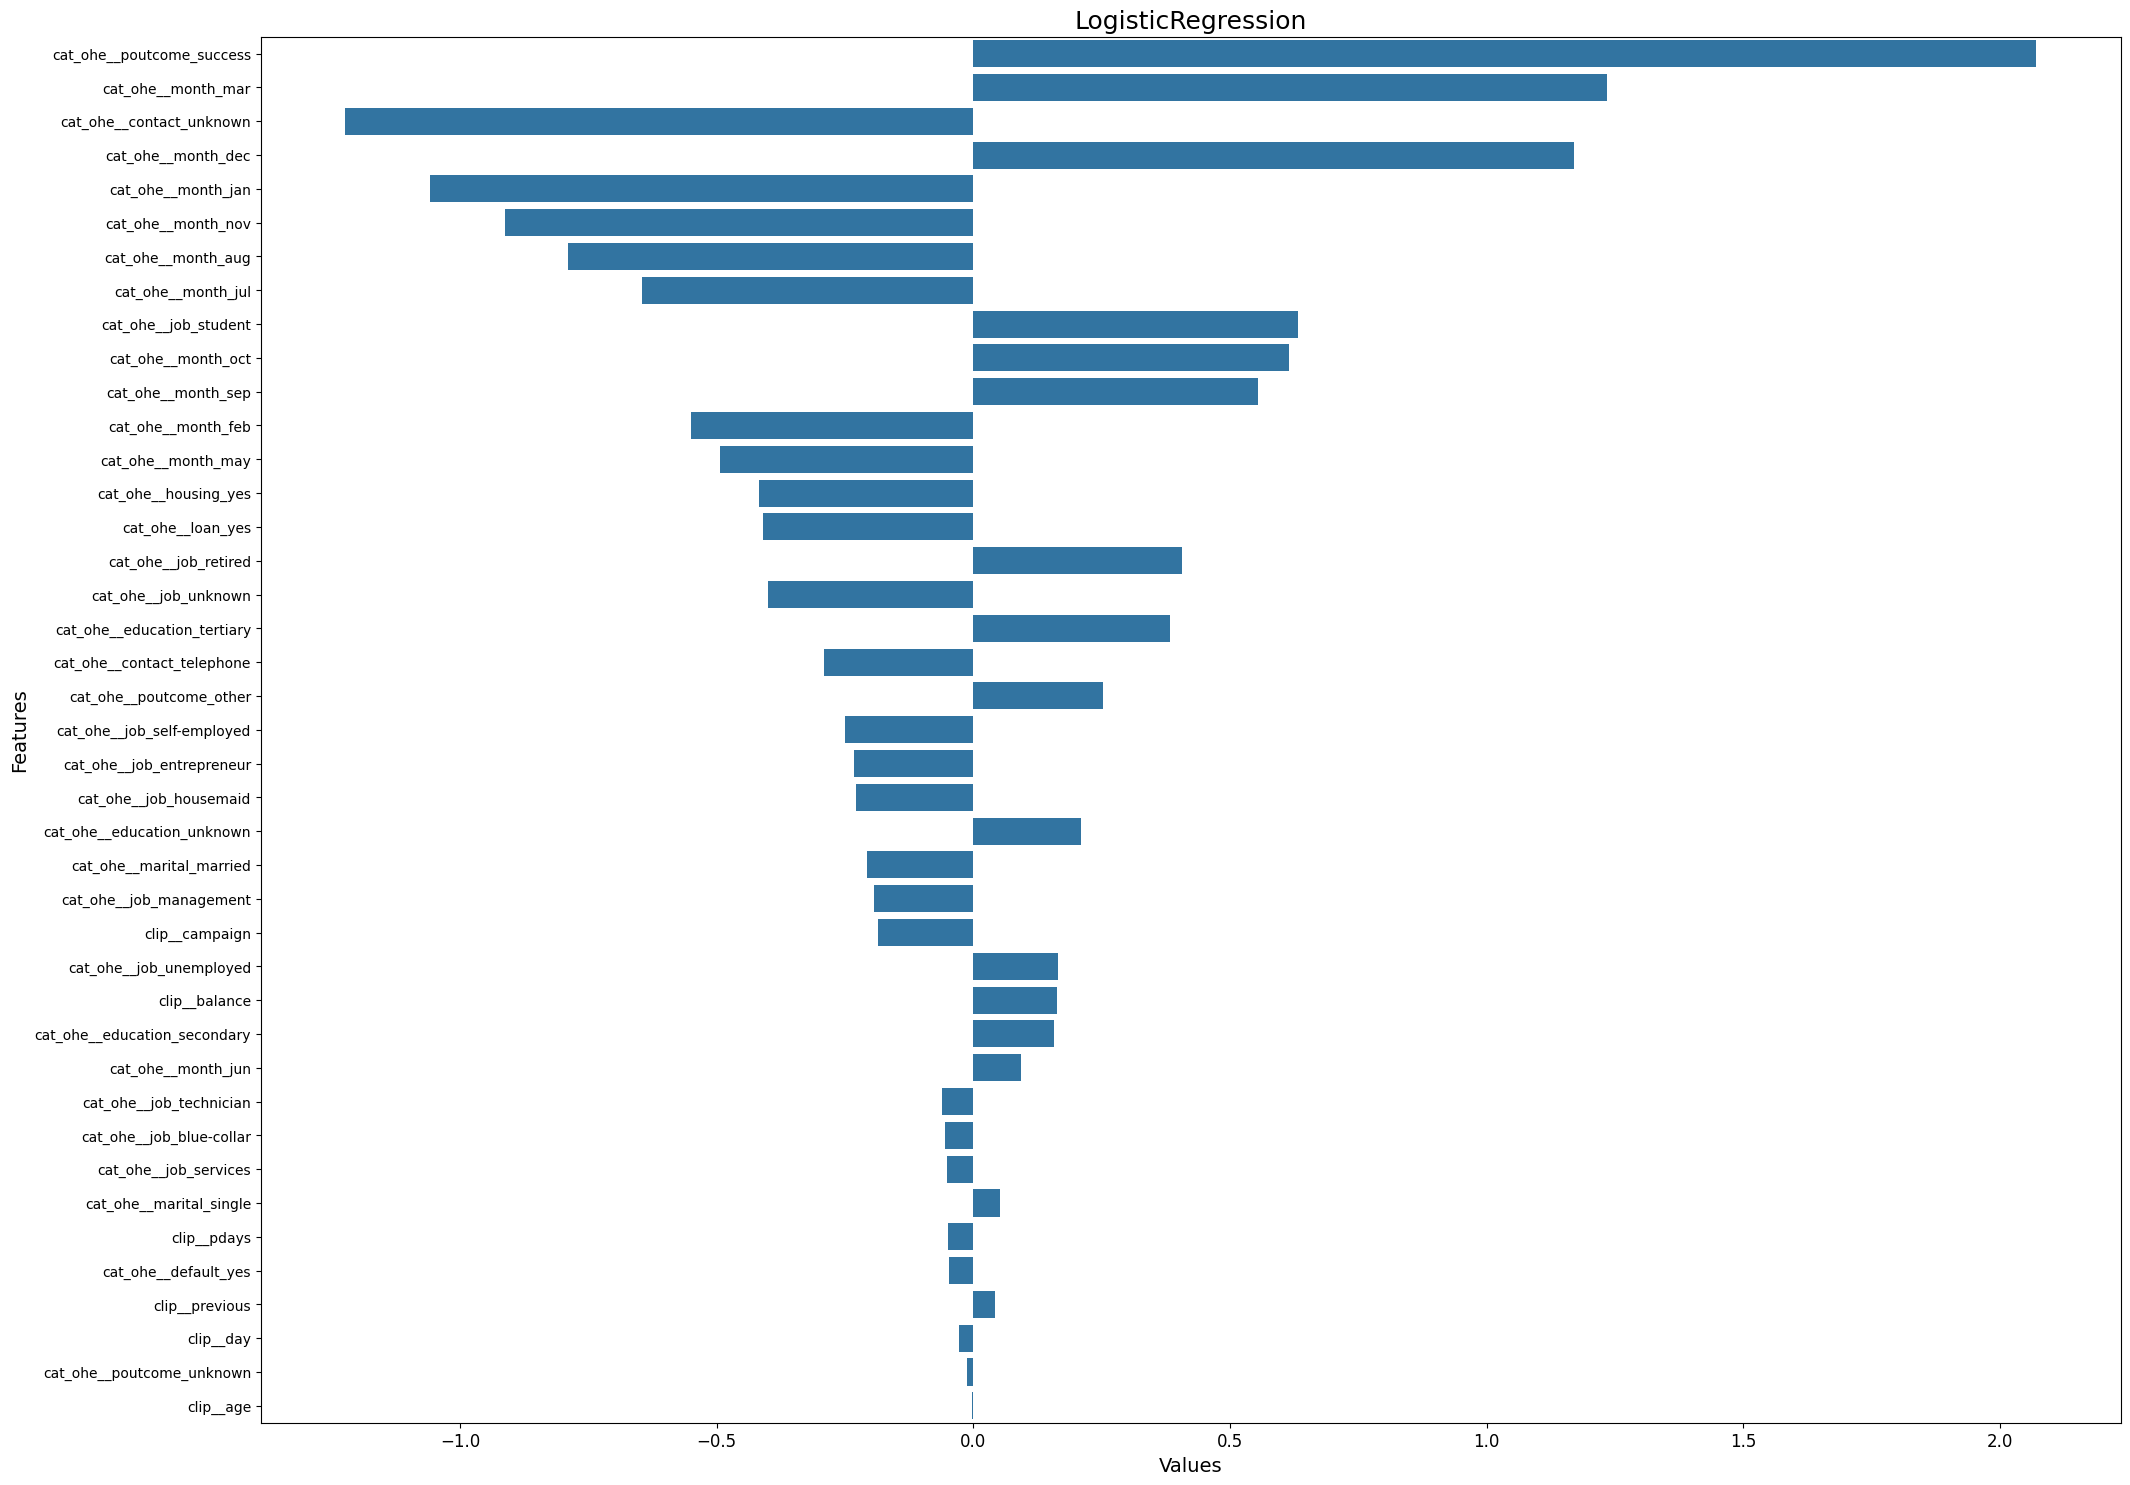

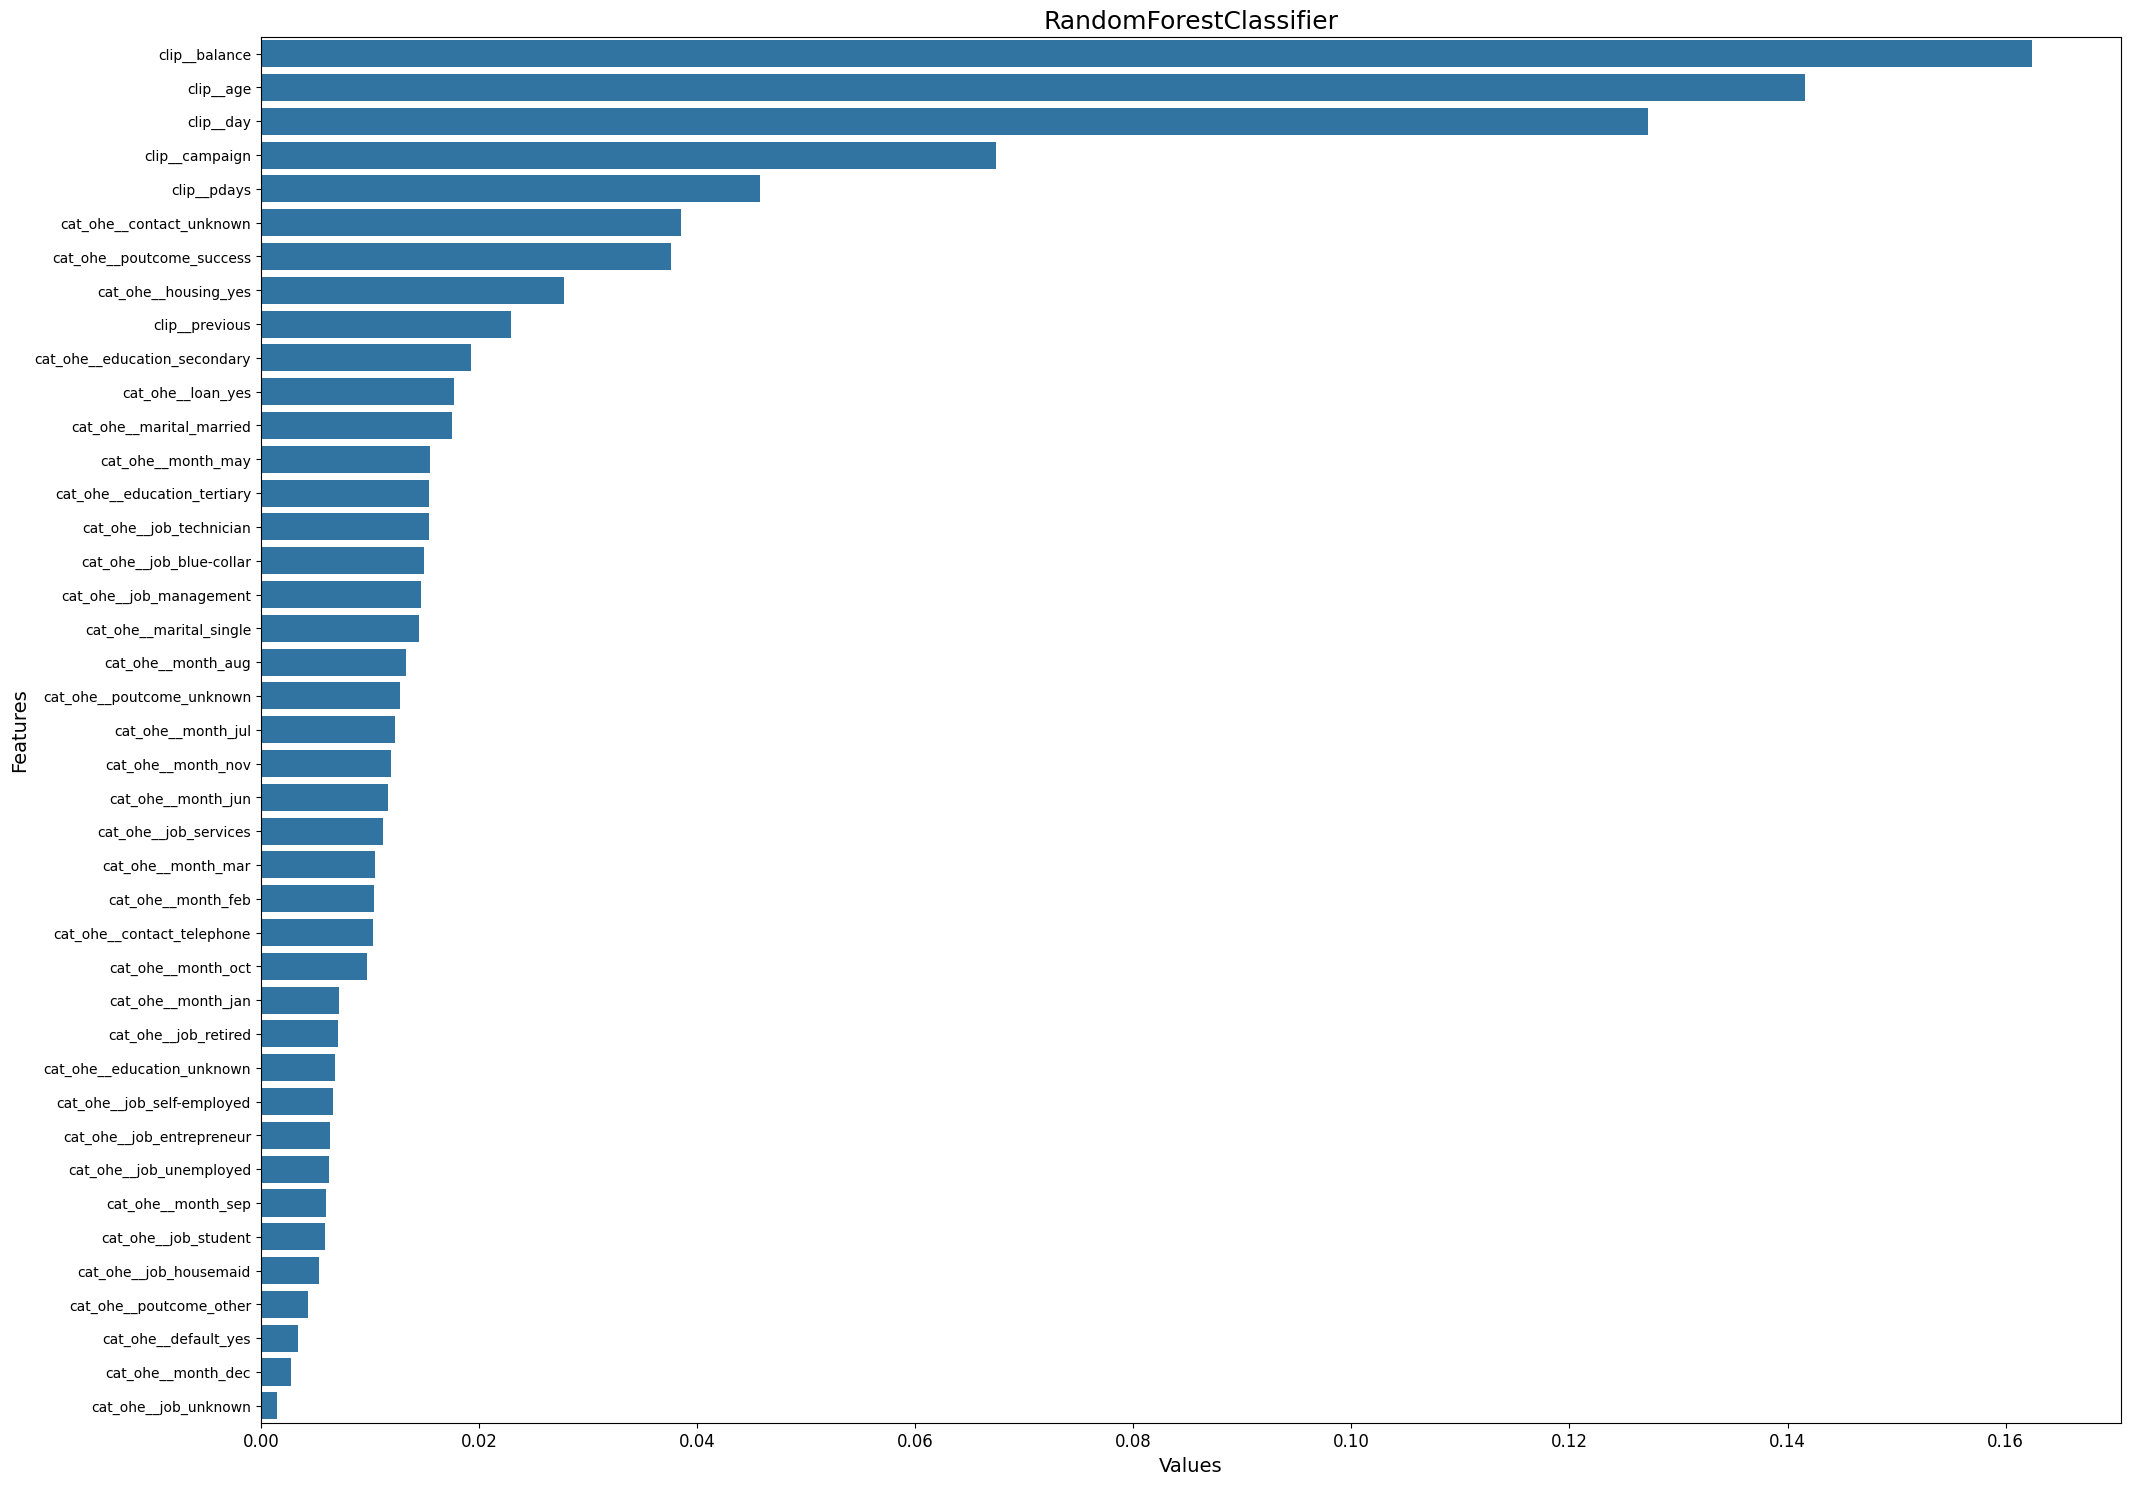

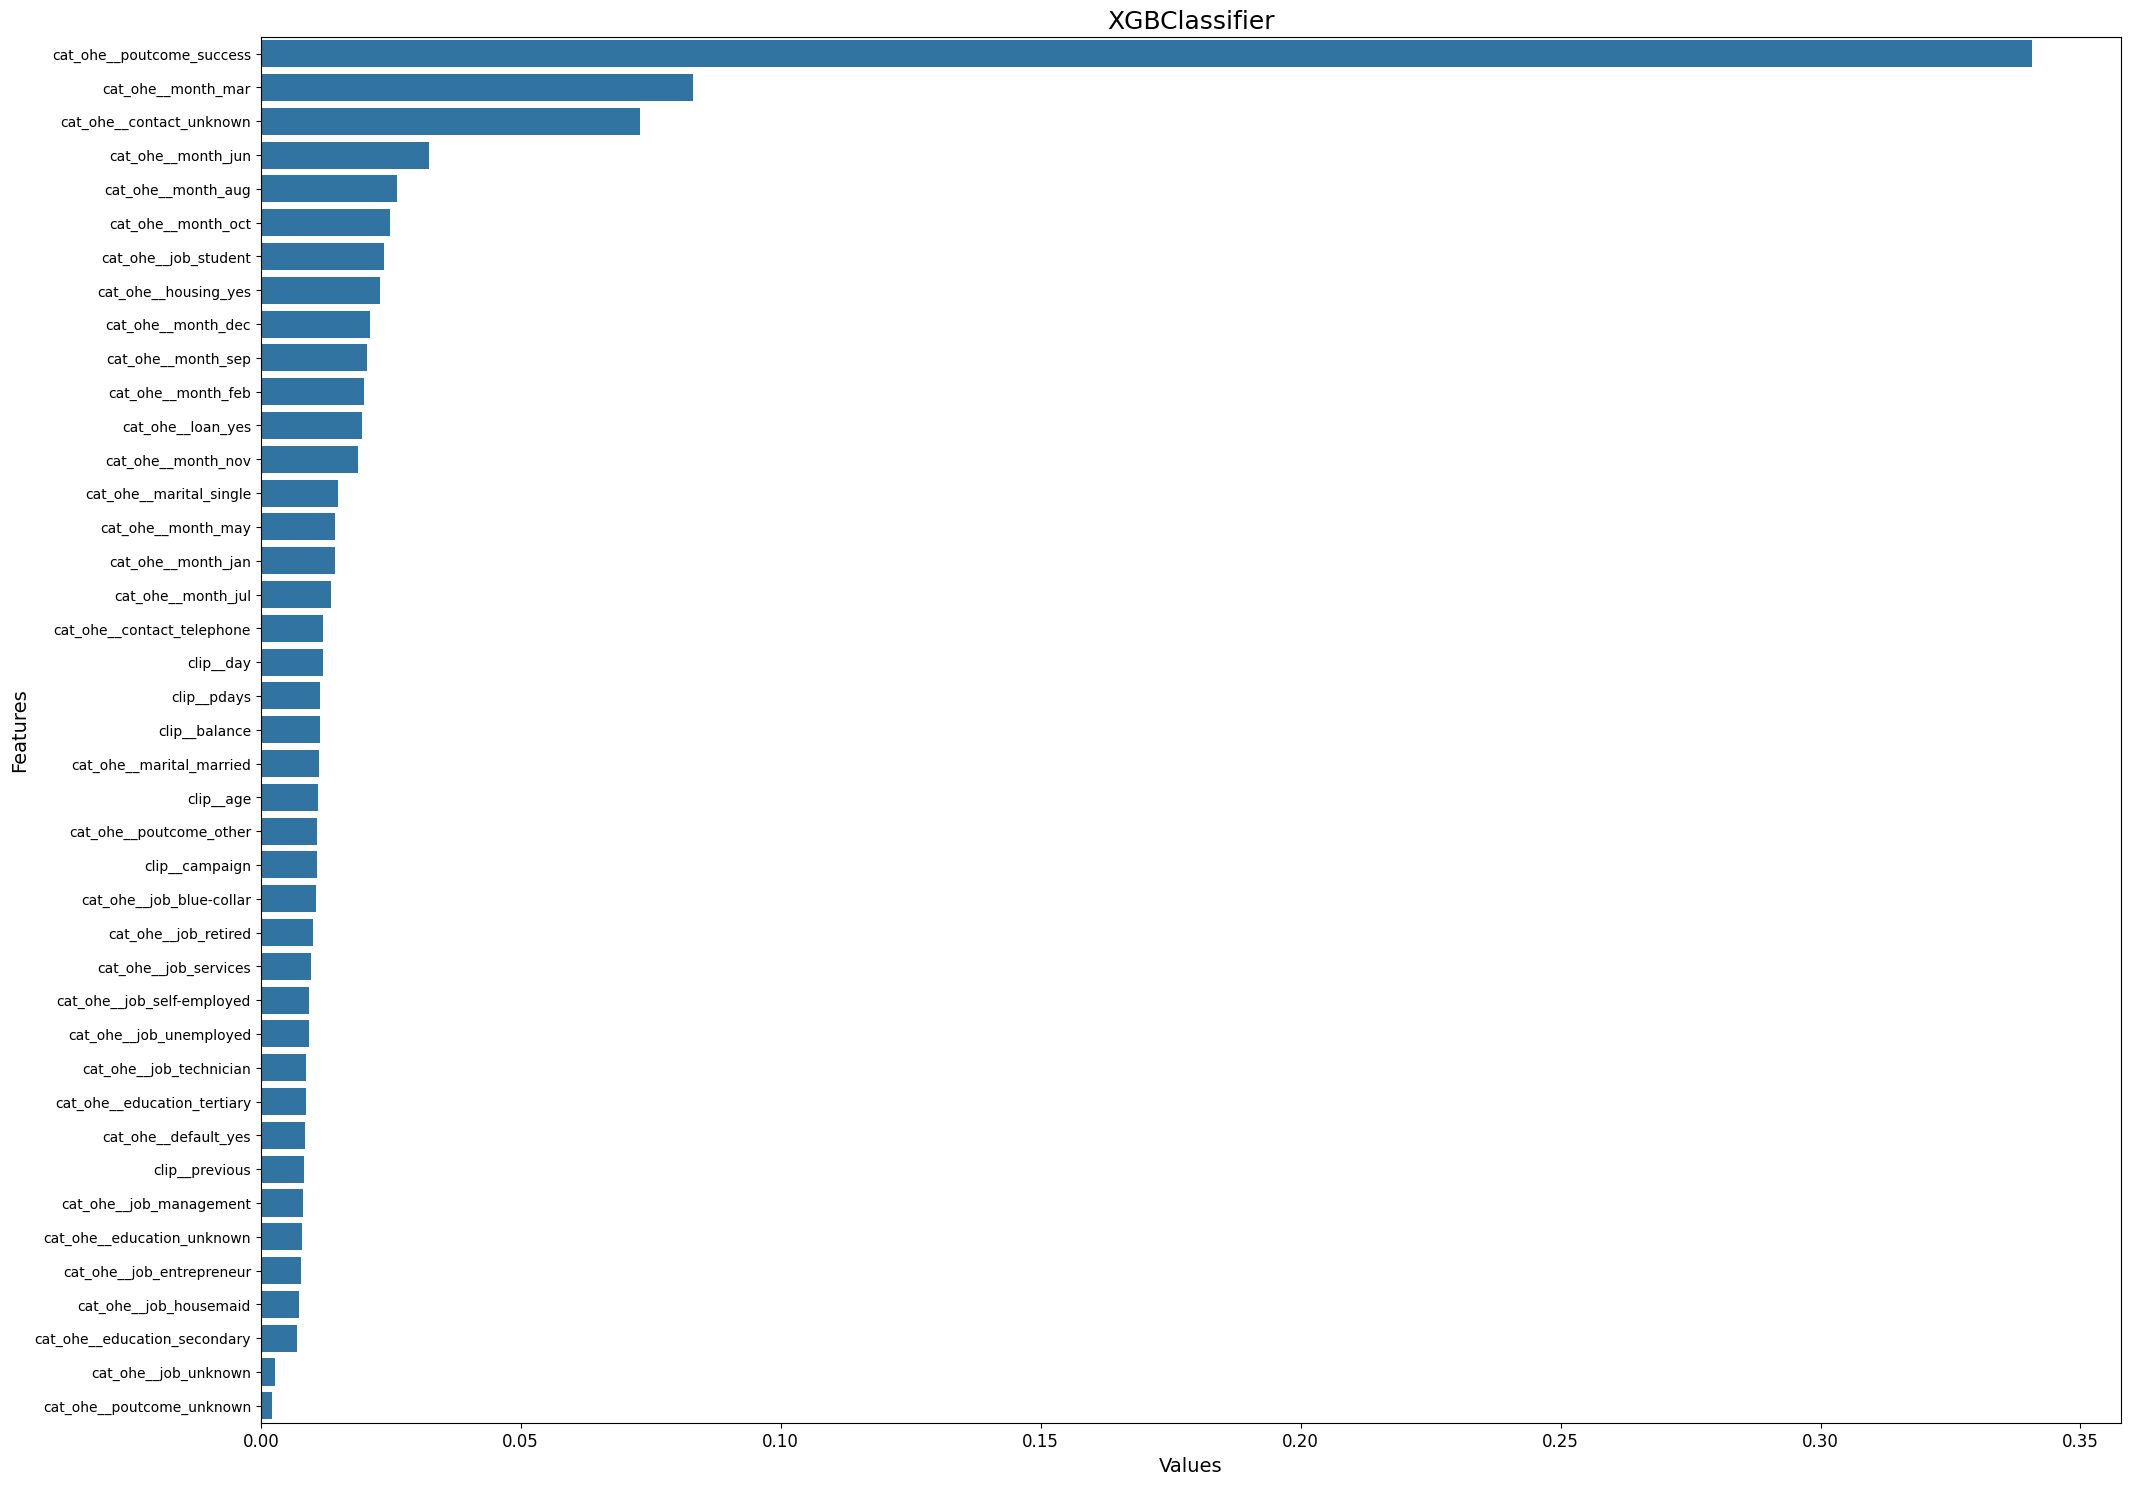

In [10]:
get_feature_importance(list_of_models_o)

## ИТОГИ

По результатм обучения моделей можно сделать вывод, что явного явного увеличения метрик не наблюдается.
При этом не забываем, что мы строим модели для привлечения клиентов на размещение депозитов в банк. В данной задаче важнее метрика recall - цена ошибки "пропустить" клиента, который готов оформить депозит выше, чем позвонить лишнему клиенту. Т.е. будем считать, что доход от размещения депозита гораздо выше, чем затраты на звонок клиенту. Поэтому если ориентироваться на метрику recall, то наилучшие показатели показали модели при обработке выбросов. Их и возьмем для улучшения метрик в рамках следующего шага - hyper_param_tuning.